# RQ4 — Quality across the complete extracted project corpus

This notebook discovers **all projects with extraction artifacts** in `data/rq4/`.
It describes coverage, code structure, static-analysis burden and their evolution;
it also provides a detailed view for any project. Counts and conclusions about
availability are computed from the current files, including failed workbook-only
extractions. Repository owners are not used as developer or agent labels.

The paper asks whether higher commit volume accompanies broader changes (H4.1),
whether attributed commits have stronger cleanliness signals (H4.2), and whether
complexity accumulates during sustained high-volume development (H4.3). These
snapshots describe structural evolution; H4.1/H4.2 and the exposure component of
H4.3 still require commit-level joins. See [the original audit](REVIEW.md).

Run with the locked environment described in [README.md](README.md). All summary
tables and figures are also written to `outputs/`. The first run aggregates
file/function exports one snapshot at a time; later runs reuse a cache that is
invalidated by input paths, sizes, modification times, analysis code and library
versions. No pairwise co-change table is loaded globally into memory.


## 1. Configuration and complete extraction inventory

The default window includes the full extraction. Set `START_DATE` and `END_DATE`
to ISO dates to restrict the analysis (for example, `2025-09-01` and `2026-02-28`
for the paper's original window). The artifact inventory always covers the full
extraction. `PROJECT_TO_INSPECT` accepts any project identifier from that inventory;
`None` selects the project with the most usable snapshots in the chosen window.


In [1]:
from pathlib import Path
import sys
import importlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

START_DATE = None
END_DATE = None
PROJECT_TO_INSPECT = None
SHOW_ALL_PROJECT_PAGES = True
REFRESH_CACHE = False

REPO_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
                  if (p / "data/rq4").is_dir() and (p / "paper/paper.tex").exists()), None)
if REPO_ROOT is None:
    raise FileNotFoundError("Run from inside the repository containing data/rq4 and paper/paper.tex")
NOTEBOOK_DIR = REPO_ROOT / "figures/rq4"
sys.path.insert(0, str(NOTEBOOK_DIR))
import rq4_analysis as rq4
importlib.reload(rq4)
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 105, "axes.titlesize": 10, "axes.labelsize": 9})
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 65)

def show_all(table):
    with pd.option_context("display.max_rows", None):
        display(table)

def export_table(table, name, index=False):
    table.to_csv(OUTPUT_DIR / f"{name}.csv", index=index)

def finish_figure(fig, name):
    fig.tight_layout()
    rq4.save_figure(fig, OUTPUT_DIR, name)
    plt.show()
    plt.close(fig)

manifest, schemas = rq4.discover(REPO_ROOT / "data/rq4")
export_table(manifest, "artifact_manifest")
export_table(schemas, "csv_schemas")
display(Markdown(
    f"Found **{manifest.project.nunique():,} projects**, **{len(manifest):,} artifact snapshots**, "
    f"**{manifest.complete_csv.sum():,} complete CSV sets**, and "
    f"**{manifest.zero_byte_workbook.sum():,} zero-byte workbooks**. "
    f"Filename dates span **{manifest.date.min().date()}–{manifest.date.max().date()}**."
))
display(schemas)
failed = manifest[~manifest.complete_csv | manifest.zero_byte_workbook]
display(failed.groupby("project").agg(incomplete_or_empty=("stem", "size")))


Found **177 projects**, **7,341 artifact snapshots**, **7,239 complete CSV sets**, and **102 zero-byte workbooks**. Filename dates span **2025-09-01–2026-04-30**.

,kind,header,files
0,files,"file, ncloc, complexity, cognitive_complexity, code_smells, b...",7239
1,functions,"file, function, start_line, end_line, size_lines",7239
2,issues,"issue_key, file, rule, rule_source, severity, status, line, m...",7239
3,pairs,"type, path, coupled_file, shared_commits",7239
4,scattering,"type, path, git_scattering, commits_analyzed, top_coupled_files",7239
5,summary,"metric, value",7239


,incomplete_or_empty
project,
Dicklesworthstone-flywheel_connectors,2
Dicklesworthstone-franken_engine,5
Dicklesworthstone-franken_node,48
Dicklesworthstone-pi_agent_rust,29
ruvnet-RuVector,6
subnirvake-vector-sh,3
tenzir-tenzir,9


## 2. Measurements and calendar policy

Six CSV families describe project metrics, analyzed files, detected function sizes,
Sonar issue details, history-based scattering entities, and co-change pairs. The
last two summarize history; they are **not the diff or breadth of the snapshot
commit**. Import counts do not establish cohesion.

**Calendar policy:** use the date encoded in each extraction filename as the
*sampling-date label*. Preserve Sonar's `last_commit_date` only as an audit field;
neither field has been validated as the exact timestamp of the selected commit.
Do not invent within-day order from a short SHA. For trajectories, take the median
of each metric across snapshots in the same project/day. For monthly summaries,
take the median of observed daily values per project/month, then summarize those
project values with equal weight. No missing days/months are filled forward or
interpreted as zero. Thus a daily median of function p95 values is a median of
snapshot quantiles, not a pooled function quantile or an end-of-day state.

NCLOC-zero denominators remain missing. Empty function exports have unknown size
distributions; zero test/coverage reports do not establish absence of tests.
`source_*` variables apply the documented path heuristic excluding vendor,
generated/build/artifact/reference directories. “Source” here means the remaining
analyzed paths, not verified first-party production code. Path-detected test NCLOC
is a static proxy and does not measure executed tests, coverage, or inline tests.


In [2]:
all_snapshots = rq4.load_snapshots(manifest, OUTPUT_DIR / "cache", refresh=REFRESH_CACHE)
inventory = rq4.project_inventory(manifest, all_snapshots)
export_table(inventory, "project_inventory", index=True)
snapshots = all_snapshots.copy()
if START_DATE is not None:
    snapshots = snapshots[snapshots.date >= pd.Timestamp(START_DATE)]
if END_DATE is not None:
    snapshots = snapshots[snapshots.date <= pd.Timestamp(END_DATE)]
if snapshots.empty:
    raise ValueError("No usable snapshots in the requested date window")
daily = rq4.daily_panel(snapshots)
monthly, paired = rq4.monthly_panels(daily)
latest_daily = daily.sort_values("date").groupby("project").tail(1).set_index("project")
endpoints = rq4.endpoint_table(daily)
export_table(snapshots, "snapshot_metrics")
export_table(daily, "project_daily_metrics")
export_table(monthly, "project_monthly_metrics")
export_table(paired, "paired_monthly_changes")
export_table(endpoints, "project_endpoints")
inventory["snapshots_in_window"] = snapshots.groupby("project").size().reindex(inventory.index, fill_value=0)
export_table(inventory, "project_inventory", index=True)
display(Markdown(
    f"Analyzing **{len(snapshots):,} snapshots**, **{len(daily):,} project-days**, "
    f"and **{snapshots.project.nunique():,} projects** in the selected window. "
    f"**{snapshots.date_mismatch.sum():,}** snapshots have different filename and Sonar dates. "
    f"**{daily.snapshots_in_day.gt(1).sum():,}** project-days contain multiple snapshots."
))
show_all(inventory)


Aggregated 500/7,239 snapshots


Aggregated 1,000/7,239 snapshots


Aggregated 1,500/7,239 snapshots


Aggregated 2,000/7,239 snapshots


Aggregated 2,500/7,239 snapshots


...

Aggregated 6,500/7,239 snapshots


Aggregated 7,000/7,239 snapshots


Aggregated 7,239/7,239 snapshots


Analyzing **7,239 snapshots**, **6,405 project-days**, and **177 projects** in the selected window. **1,863** snapshots have different filename and Sonar dates. **378** project-days contain multiple snapshots.

,artifact_snapshots,usable_snapshots,complete_csv_snapshots,zero_byte_workbooks,first_artifact_date,last_artifact_date,observed_days,date_mismatches,issue_snapshots,function_snapshots,zero_ncloc_snapshots,snapshots_in_window
project,,,,,,,,,,,,
Dicklesworthstone-aadc,18,18,18,0,2026-01-20,2026-04-25,18,8,18,18,0,18
Dicklesworthstone-acip,14,14,14,0,2026-01-04,2026-03-21,10,7,0,0,14,14
Dicklesworthstone-agentic_coding_flywheel_setup,208,208,208,0,2025-12-19,2026-04-30,125,60,0,207,0,208
Dicklesworthstone-asupersync,62,62,62,0,2026-01-16,2026-03-12,55,5,61,62,0,62
Dicklesworthstone-asupersync_ansi_c,38,38,38,0,2026-02-26,2026-04-25,38,5,34,37,4,38
Dicklesworthstone-automated_plan_reviser_pro,20,20,20,0,2026-01-12,2026-03-21,16,8,0,0,20,20
Dicklesworthstone-beads_rust,92,92,92,0,2026-01-15,2026-04-30,92,12,90,90,2,92
Dicklesworthstone-beads_viewer,72,72,72,0,2025-11-26,2026-04-28,72,14,72,72,0,72
Dicklesworthstone-beads_viewer_rust,48,48,48,0,2026-02-18,2026-04-24,48,10,48,48,0,48


## 3. Coverage and measurement availability

The inventory above includes every project, even one with no usable summaries.
The coverage plot shows observed days and available projects, not developer
activity. Missing or unsupported observations remain visible in the tables.


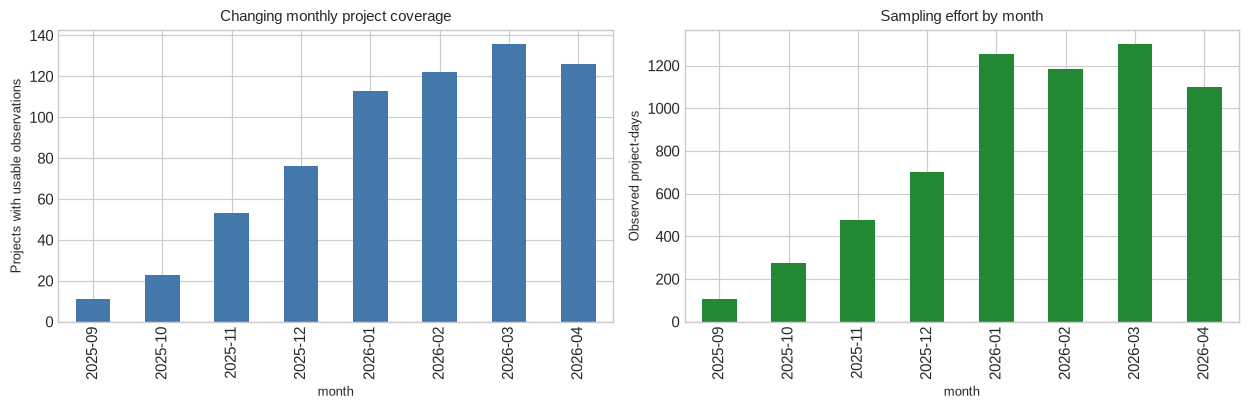

,numeric_values,zeros,positive,non_numeric_or_missing
metric,,,,
ncloc,7239,325,6914,0
complexity,7239,499,6740,0
tests,7239,7239,0,0
coverage,7239,7239,0,0
functions,7239,528,6711,0
violations,7239,539,6700,0
coupling_efferent,7239,1313,5926,0
ca_afferent_coupling,7239,2194,5045,0


**93 summary metrics are identically zero.** Function rows occur in **157 projects**; issue details occur in **32 projects**. There are **5,363** empty issue exports with positive summary violations and **734** populated exports with counts differing from the summary. Issue composition below describes the exported subset.

In [3]:
coverage = daily.assign(month=daily.date.dt.to_period("M").astype(str)).groupby(["project", "month"]).size().unstack(fill_value=0)
coverage = coverage.reindex(inventory.index, fill_value=0)
export_table(coverage, "coverage_project_month", index=True)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
coverage.gt(0).sum().plot.bar(ax=axes[0], color="#4477aa")
axes[0].set_ylabel("Projects with usable observations")
axes[0].set_title("Changing monthly project coverage")
coverage.sum().plot.bar(ax=axes[1], color="#228833")
axes[1].set_ylabel("Observed project-days")
axes[1].set_title("Sampling effort by month")
finish_figure(fig, "corpus_coverage")

metric_keys = pd.read_csv(manifest.loc[manifest.has_summary, "summary_path"].iloc[0])["metric"]
availability_rows = []
for metric in metric_keys:
    values = pd.to_numeric(snapshots[metric], errors="coerce")
    availability_rows.append({"metric": metric, "numeric_values": values.notna().sum(),
                              "zeros": values.eq(0).sum(), "positive": values.gt(0).sum(),
                              "non_numeric_or_missing": values.isna().sum()})
availability = pd.DataFrame(availability_rows).set_index("metric")
export_table(availability, "metric_availability", index=True)
display(availability.loc[["ncloc", "complexity", "tests", "coverage", "functions", "violations", "coupling_efferent", "ca_afferent_coupling"]])
empty_issues_nonzero = snapshots.detailed_issue_rows.eq(0) & snapshots.violations.gt(0)
populated_issues = snapshots.detailed_issue_rows.gt(0)
issue_mismatch = populated_issues & snapshots.detailed_issue_rows.ne(snapshots.violations)
display(Markdown(
    f"**{availability.zeros.eq(len(snapshots)).sum()} summary metrics are identically zero.** "
    f"Function rows occur in **{snapshots.loc[snapshots.function_rows.gt(0), 'project'].nunique()} projects**; "
    f"issue details occur in **{snapshots.loc[populated_issues, 'project'].nunique()} projects**. "
    f"There are **{empty_issues_nonzero.sum():,}** empty issue exports with positive summary violations "
    f"and **{issue_mismatch.sum():,}** populated exports with counts differing from the summary. "
    "Issue composition below describes the exported subset."
))


## 4. Cross-project distributions and language context

Each point in the ECDF is one project's latest observed daily median in the
chosen window. Latest dates vary; this is not a synchronized end-of-study
comparison. The symmetric logarithmic x-axis retains zero values and long tails.
NCLOC and size are descriptive, not quality scores. There is no pooling of all
files/functions across projects, which would overweight the largest repositories.
File-size p95 uses files with positive analyzed NCLOC; projects without any such
files have a missing size quantile rather than a zero-size result.


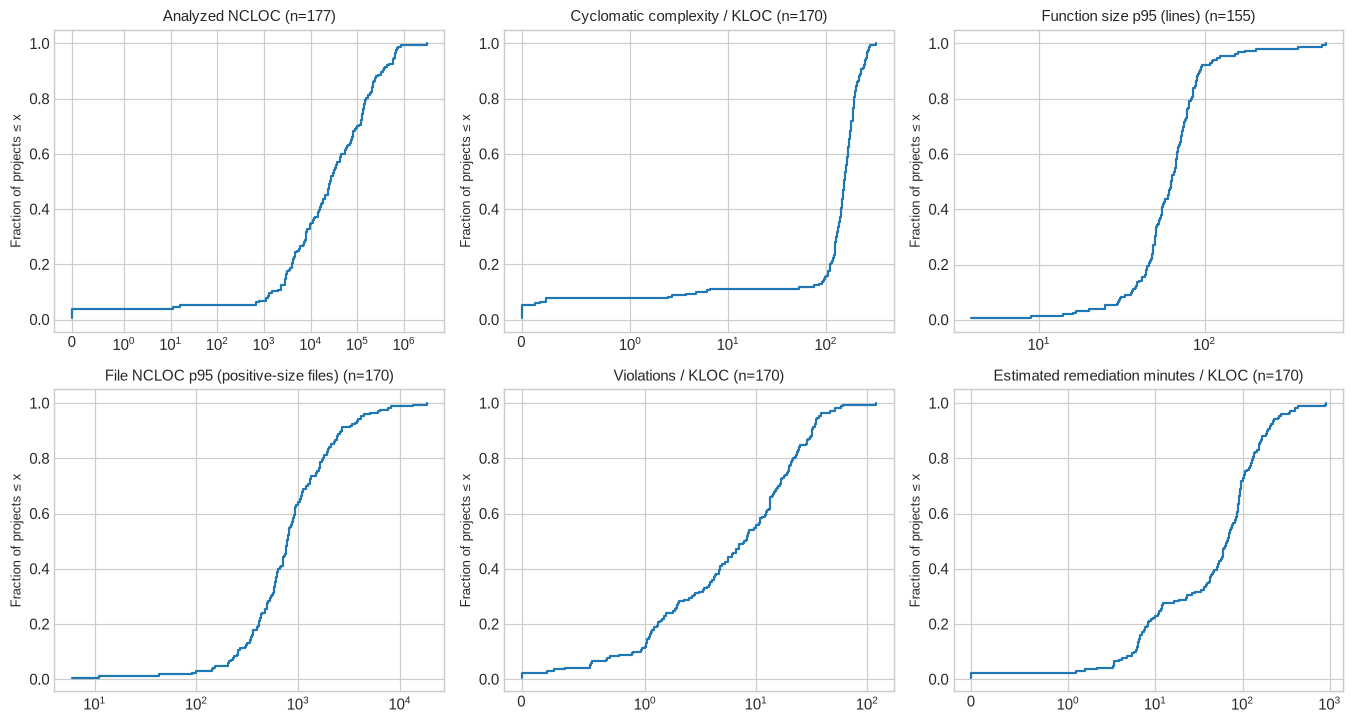

,date,snapshots_in_day,ncloc,complexity_per_kloc,function_p95,file_size_p95,violations_per_kloc,debt_per_kloc,comment_lines_density,duplicated_lines_density,test_path_ncloc_share,artifact_ncloc_share
project,,,,,,,,,,,,
tenzir-tenzir,2025-09-02,1,4146.0,176.073324,30.00,400.50,12.542209,92.378196,9.8,0.0,34.732272,0.000000
Dicklesworthstone-ultimate_bug_scanner,2025-11-16,1,0.0,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
obra-external-subagents,2025-12-24,1,7290.0,190.672154,29.70,358.25,8.641975,69.272977,1.5,1.6,35.020576,0.000000
obra-wordiest,2025-12-28,1,5789.0,0.172741,NaN,146.65,16.237692,94.144066,1.2,0.0,17.049577,0.000000
URF365LLC-SELF-AI,2026-01-01,1,254108.0,152.521762,68.00,471.60,23.706456,117.237553,12.7,2.6,26.319518,0.000000
steipete-sweetlink,2026-01-01,1,19767.0,203.622199,46.15,427.35,8.549603,50.741134,0.9,4.7,25.330096,1.704862
obra-winby,2026-01-02,1,4554.0,0.219587,NaN,2694.50,34.914361,183.355292,11.9,0.0,0.000000,0.000000
subnirvake-vector-sh,2026-01-05,1,627586.0,162.556207,50.00,709.20,9.922146,58.916228,16.4,4.8,9.002113,0.000000
ruvnet-RuVector,2026-01-05,1,627586.0,162.556207,50.00,709.20,9.922146,58.916228,16.4,4.8,9.002113,0.000000


Exact latest-snapshot detail views below include **173 projects** with one snapshot on their latest date. **4 projects** have ambiguous latest-day order and are excluded from these detail views only. They remain in all daily, monthly and trajectory analyses.

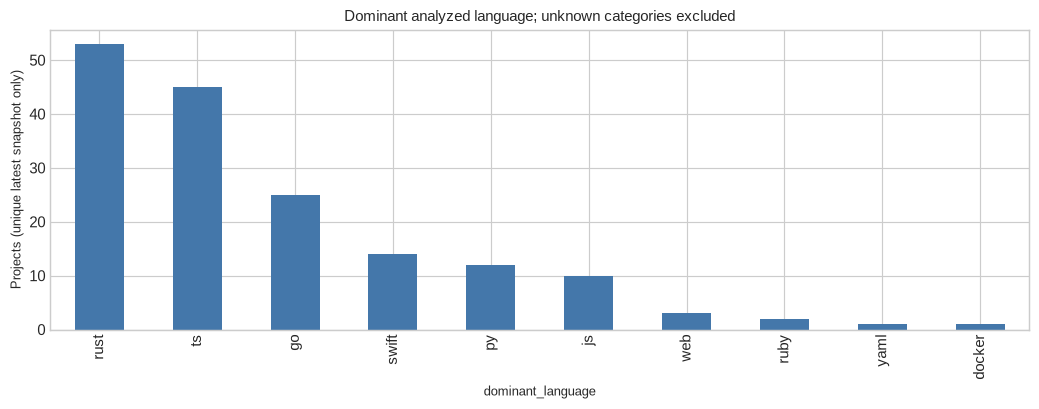

ncloc           complexity_per_kloc              \
                  count    median               count      median   
dominant_language                                                   
docker                1      11.0                   1    0.000000   
go                   25   20748.0                  25  187.817082   
js                   10    5850.0                  10  237.245905   
py                   12   16181.0                  12  159.211044   
ruby                  2     685.5                   2   64.145017   
rust                 53  120698.0                  53  136.482294   
swift                14    8097.5                  14    0.059179   
ts                   45   25667.0                  45  177.232039   
web                   3    8300.0                   3    6.144578   
yaml                  1    2987.0                   1    0.000000   

                  function_p95         file_size_p95            \
                         count  median         count    median   
dominant_language                                                
docker                       0     NaN             1    11.000   
go                          25  73.250            25   598.000   
js                           8  60.275            10   619.125   
py                          12  56.125            12   883.500   
ruby                         2  16.350             2    67.075   
rust                        53  55.000            53  1930.550   
swift                        3  89.400            14   483.300   
ts                          45  68.000            45   592.750   
web                          3  51.000             3  7638.400   
yaml                         0     NaN             1   204.100   

                  violations_per_kloc            debt_per_kloc              
                                count     median         count      median  
dominant_language                                                           
docker                              1   0.000000             1    0.000000  
go                                 25   4.631091            25   67.457309  
js                                 10  36.187318            10  225.196578  
py                                 12   9.454695            12   93.073853  
ruby                                2   0.000000             2    0.000000  
rust                               53   1.202158            53    7.616179  
swift                              14   8.762292            14   53.308956  
ts                                 45  19.261001            45  100.835438  
web                                 3  20.779221             3   42.857143  
yaml                                1  31.804486             1   97.087379

In [4]:
distribution_metrics = ["ncloc", "complexity_per_kloc", "function_p95", "file_size_p95", "violations_per_kloc", "debt_per_kloc"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, metric in zip(axes.flat, distribution_metrics):
    values = latest_daily[metric].dropna().sort_values()
    ax.step(values, np.arange(1, len(values) + 1) / len(values) if len(values) else [], where="post")
    ax.set_xscale("symlog", linthresh=1)
    label = 'File NCLOC p95 (positive-size files)' if metric == 'file_size_p95' else rq4.METRICS.get(metric, metric)
    ax.set_title(f"{label} (n={len(values)})")
    ax.set_ylabel("Fraction of projects ≤ x")
finish_figure(fig, "latest_project_distributions")
latest_summary = latest_daily[["date", "snapshots_in_day", *distribution_metrics, "comment_lines_density", "duplicated_lines_density", "test_path_ncloc_share", "artifact_ncloc_share"]]
export_table(latest_summary, "latest_project_summary", index=True)
show_all(latest_summary)

details = rq4.latest_details(manifest, snapshots)
export_table(details["ambiguous_latest"].rename("snapshots_on_latest_day"), "ambiguous_latest_days", index=True)
display(Markdown(
    f"Exact latest-snapshot detail views below include **{len(details['selected'])} projects** "
    f"with one snapshot on their latest date. **{len(details['ambiguous_latest'])} projects** "
    "have ambiguous latest-day order and are excluded from these detail views only. "
    "They remain in all daily, monthly and trajectory analyses."
))
if not details["languages"].empty:
    language = details["languages"].pivot_table(index="project", columns="language", values="ncloc", aggfunc="sum", fill_value=0)
    dominant = language.idxmax(axis=1).rename("dominant_language")
    export_table(language, "latest_language_ncloc", index=True)
    counts = dominant.value_counts()
    fig, ax = plt.subplots(figsize=(10, 4))
    counts.plot.bar(ax=ax, color="#4477aa")
    ax.set_ylabel("Projects (unique latest snapshot only)")
    ax.set_title("Dominant analyzed language; unknown categories excluded")
    finish_figure(fig, "dominant_languages")
    language_comparison = latest_daily.join(dominant).groupby("dominant_language")[distribution_metrics].agg(["count", "median"])
    display(language_comparison)
    export_table(language_comparison, "quality_by_dominant_language", index=True)


## 5. Corpus-wide evolution: levels and comparable changes

The first figure shows the median and interquartile range of project-month
medians. Every project has equal weight within a month. Project membership
changes, so a shift in this curve does not establish deterioration within
projects. The tables report the nonmissing project count for every metric/month.

The second figure addresses this composition problem by pairing **the same
project in adjacent calendar months** and plotting the distribution of its
absolute change. No pair bridges an unobserved month. The paired cohort can
still change between intervals, and these descriptive changes are not causal
effects of AI or commit volume. Comment/duplication density differences, when
used, are percentage points, not relative percentages.


,ncloc,complexity_per_kloc,cognitive_per_kloc,violations_per_kloc,debt_per_kloc,function_p95,comment_lines_density,duplicated_lines_density
month,,,,,,,,
2025-09-01,11,11,11,11,11,11,11,11
2025-10-01,23,21,21,21,21,21,23,23
2025-11-01,53,50,50,50,50,44,53,53
2025-12-01,76,71,71,71,71,64,76,76
2026-01-01,113,106,106,106,106,97,113,113
2026-02-01,122,115,115,115,115,109,122,122
2026-03-01,136,129,129,129,129,119,136,136
2026-04-01,126,123,123,123,123,112,126,126


,ncloc,complexity_per_kloc,cognitive_per_kloc,violations_per_kloc,debt_per_kloc,function_p95,comment_lines_density,duplicated_lines_density
month,,,,,,,,
2025-10-01,9,9,9,9,9,9,9,9
2025-11-01,21,19,19,19,19,19,21,21
2025-12-01,47,45,45,45,45,39,47,47
2026-01-01,71,66,66,66,66,59,71,71
2026-02-01,87,79,79,79,79,75,87,87
2026-03-01,114,107,107,107,107,101,114,114
2026-04-01,104,100,100,100,100,92,104,104


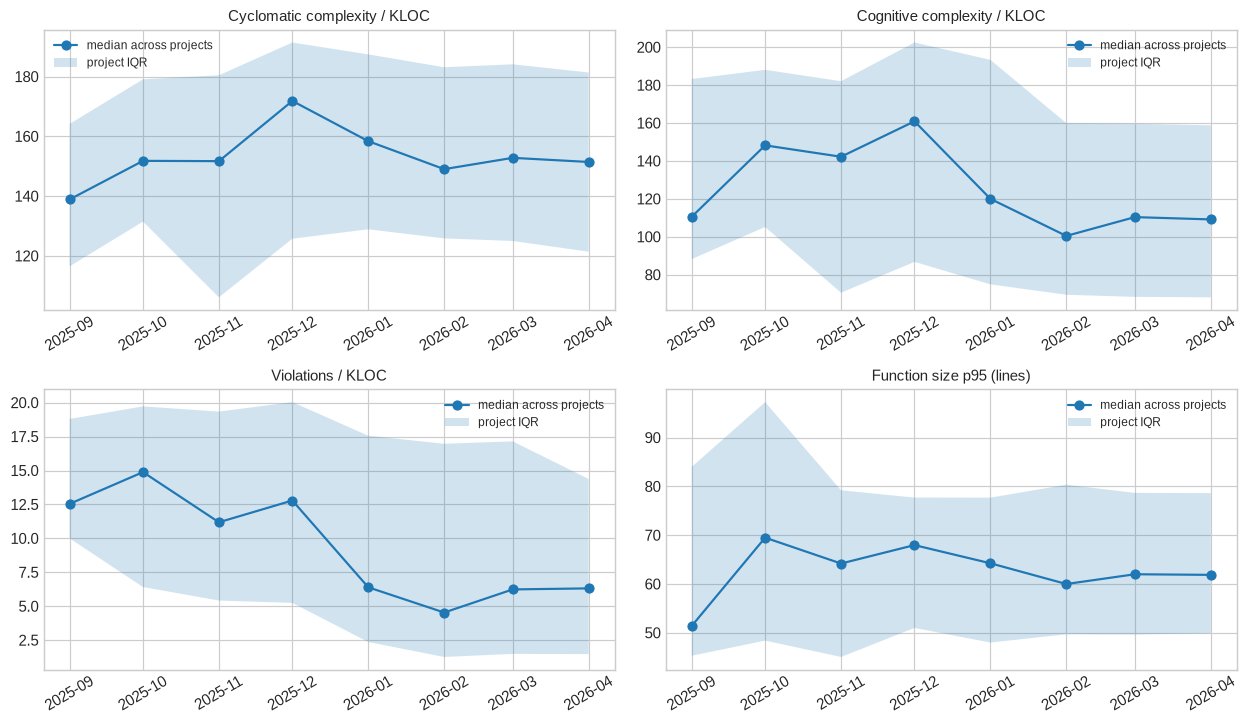

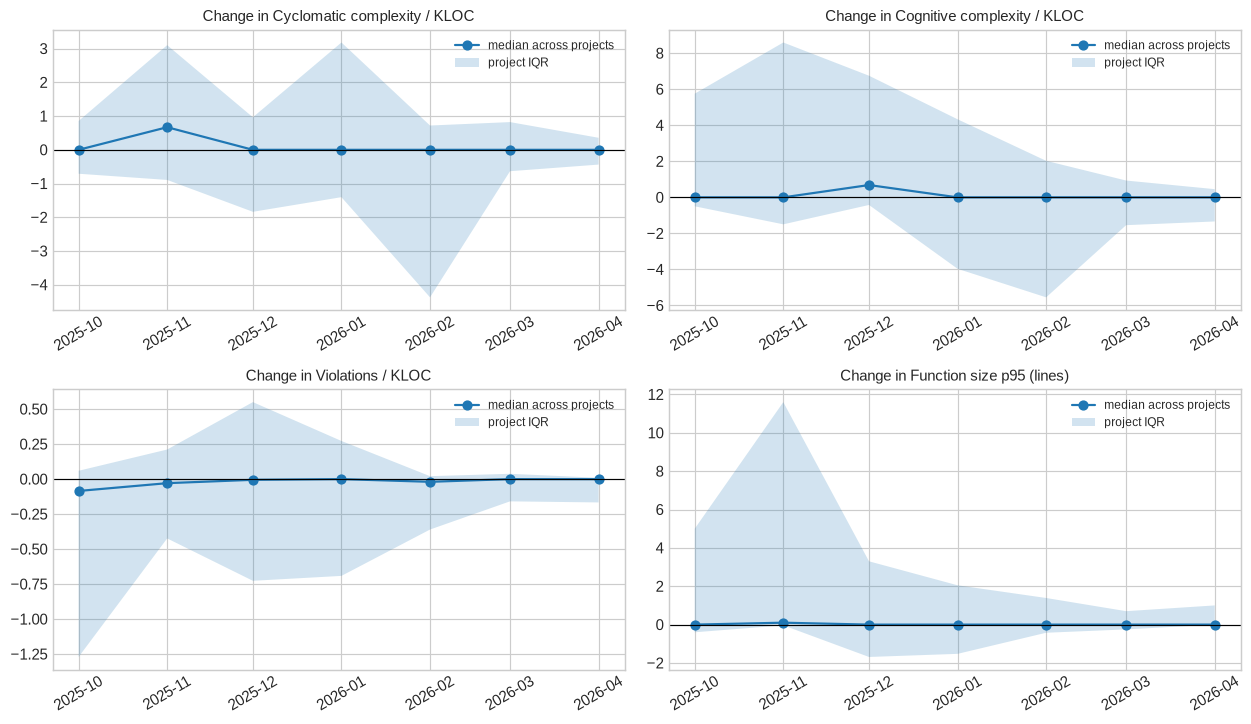

In [5]:
trend_metrics = ["complexity_per_kloc", "cognitive_per_kloc", "violations_per_kloc", "function_p95"]
monthly_counts = monthly.groupby("month")[list(rq4.METRICS)].count()
paired_counts = paired.groupby("month")[[m + "_delta" for m in rq4.METRICS]].count()
display(monthly_counts)
display(paired_counts.rename(columns=lambda c: c.removesuffix("_delta")))
export_table(monthly_counts, "monthly_denominators", index=True)
export_table(paired_counts, "paired_monthly_denominators", index=True)
for table, is_delta, name in [(monthly, False, "monthly_quality_levels"), (paired, True, "paired_monthly_quality_changes")]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    for ax, metric in zip(axes.flat, trend_metrics):
        col = metric + "_delta" if is_delta else metric
        q = table.groupby("month")[col].quantile([.25, .5, .75]).unstack()
        if not q.empty:
            ax.plot(q.index, q[.5], "o-", label="median across projects")
            ax.fill_between(q.index, q[.25], q[.75], alpha=.2, label="project IQR")
            if is_delta:
                ax.axhline(0, color="black", lw=.8)
            ax.legend(fontsize=8)
        else:
            ax.text(.5, .5, "No adjacent-month pairs", ha="center", transform=ax.transAxes)
        ax.set_title(("Change in " if is_delta else "") + rq4.METRICS[metric])
        ax.tick_params(axis="x", rotation=30)
    finish_figure(fig, name)


## 6. Every project's trajectory and endpoint summary

Every project with a usable snapshot receives a panel, paginated in alphabetical
order. Axes vary by project to show local evolution; consult the ECDFs and tables
for comparisons of scale. Dashed curves apply the same artifact-path exclusions
at **every snapshot**, providing a longitudinal sensitivity check. A one-day
project has a point, not an estimated trend. A project without positive NCLOC
is labeled explicitly. Connecting sampled dates does not imply daily observation.

All pages are saved to `outputs/all_project_trajectories.pdf`, even when
`SHOW_ALL_PROJECT_PAGES=False` suppresses their inline display.


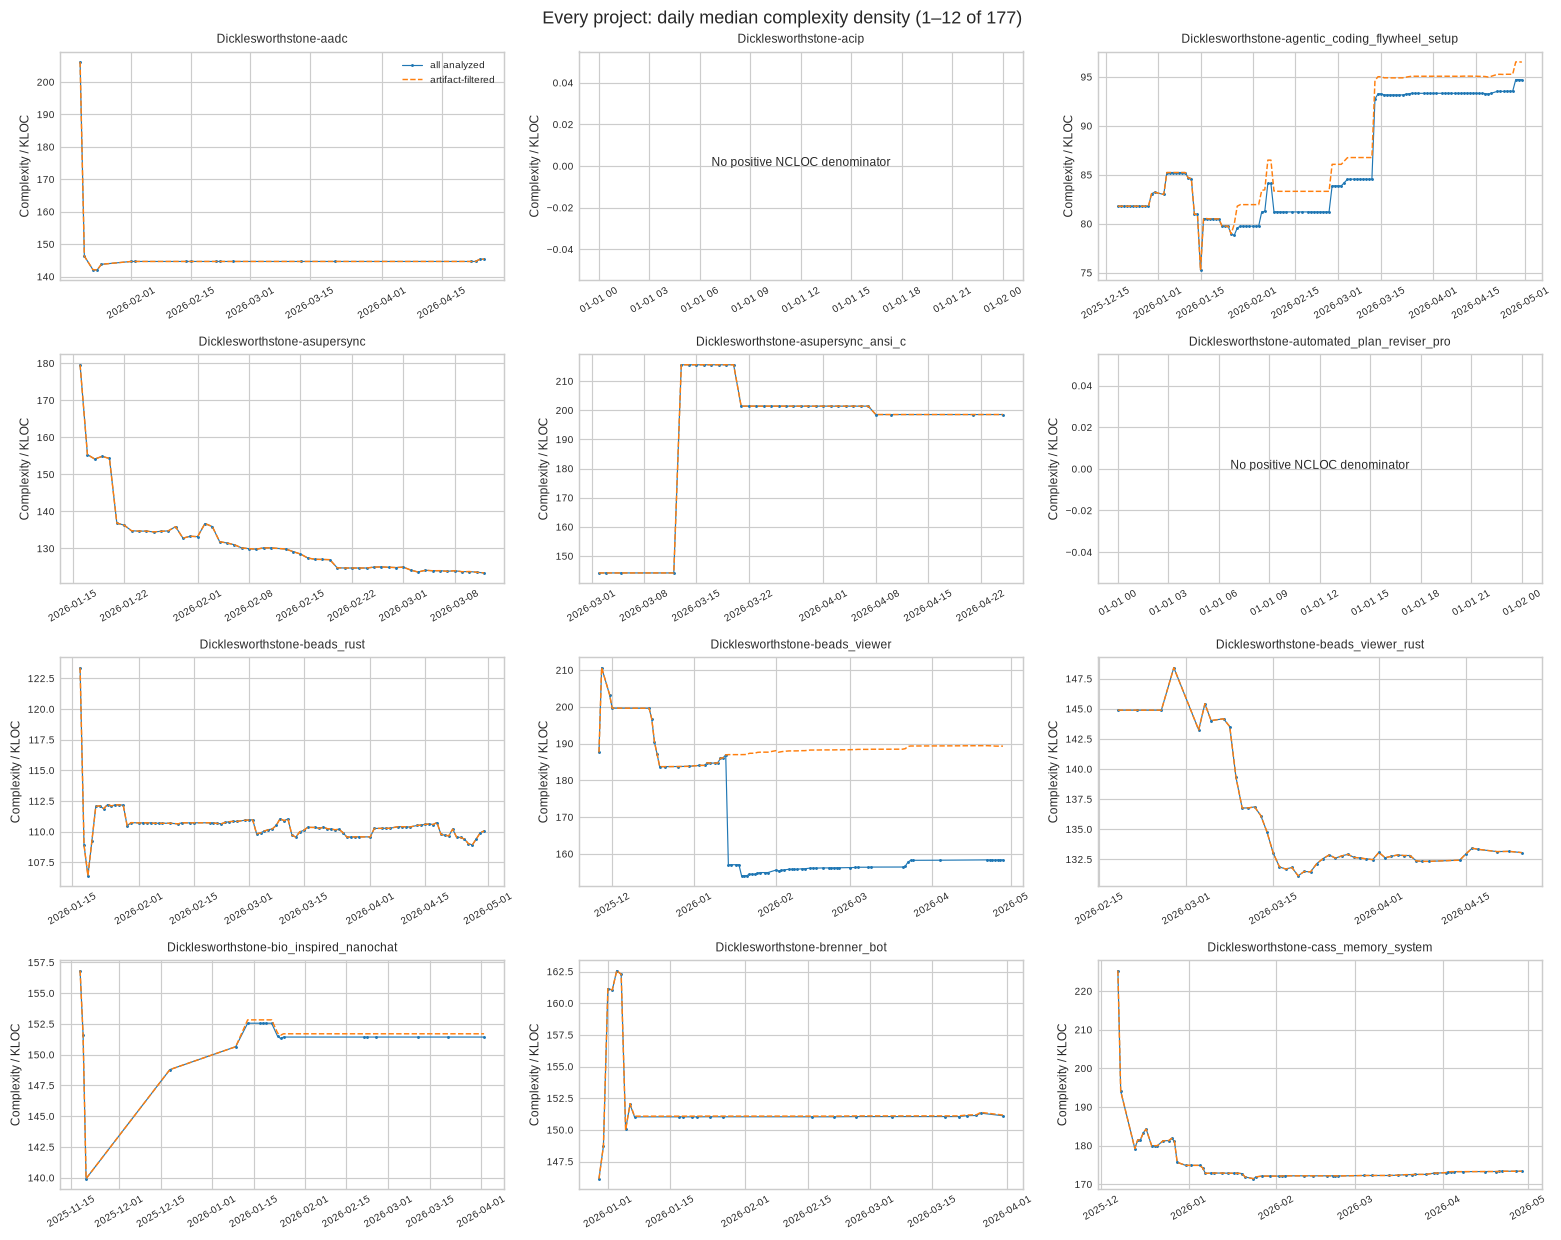

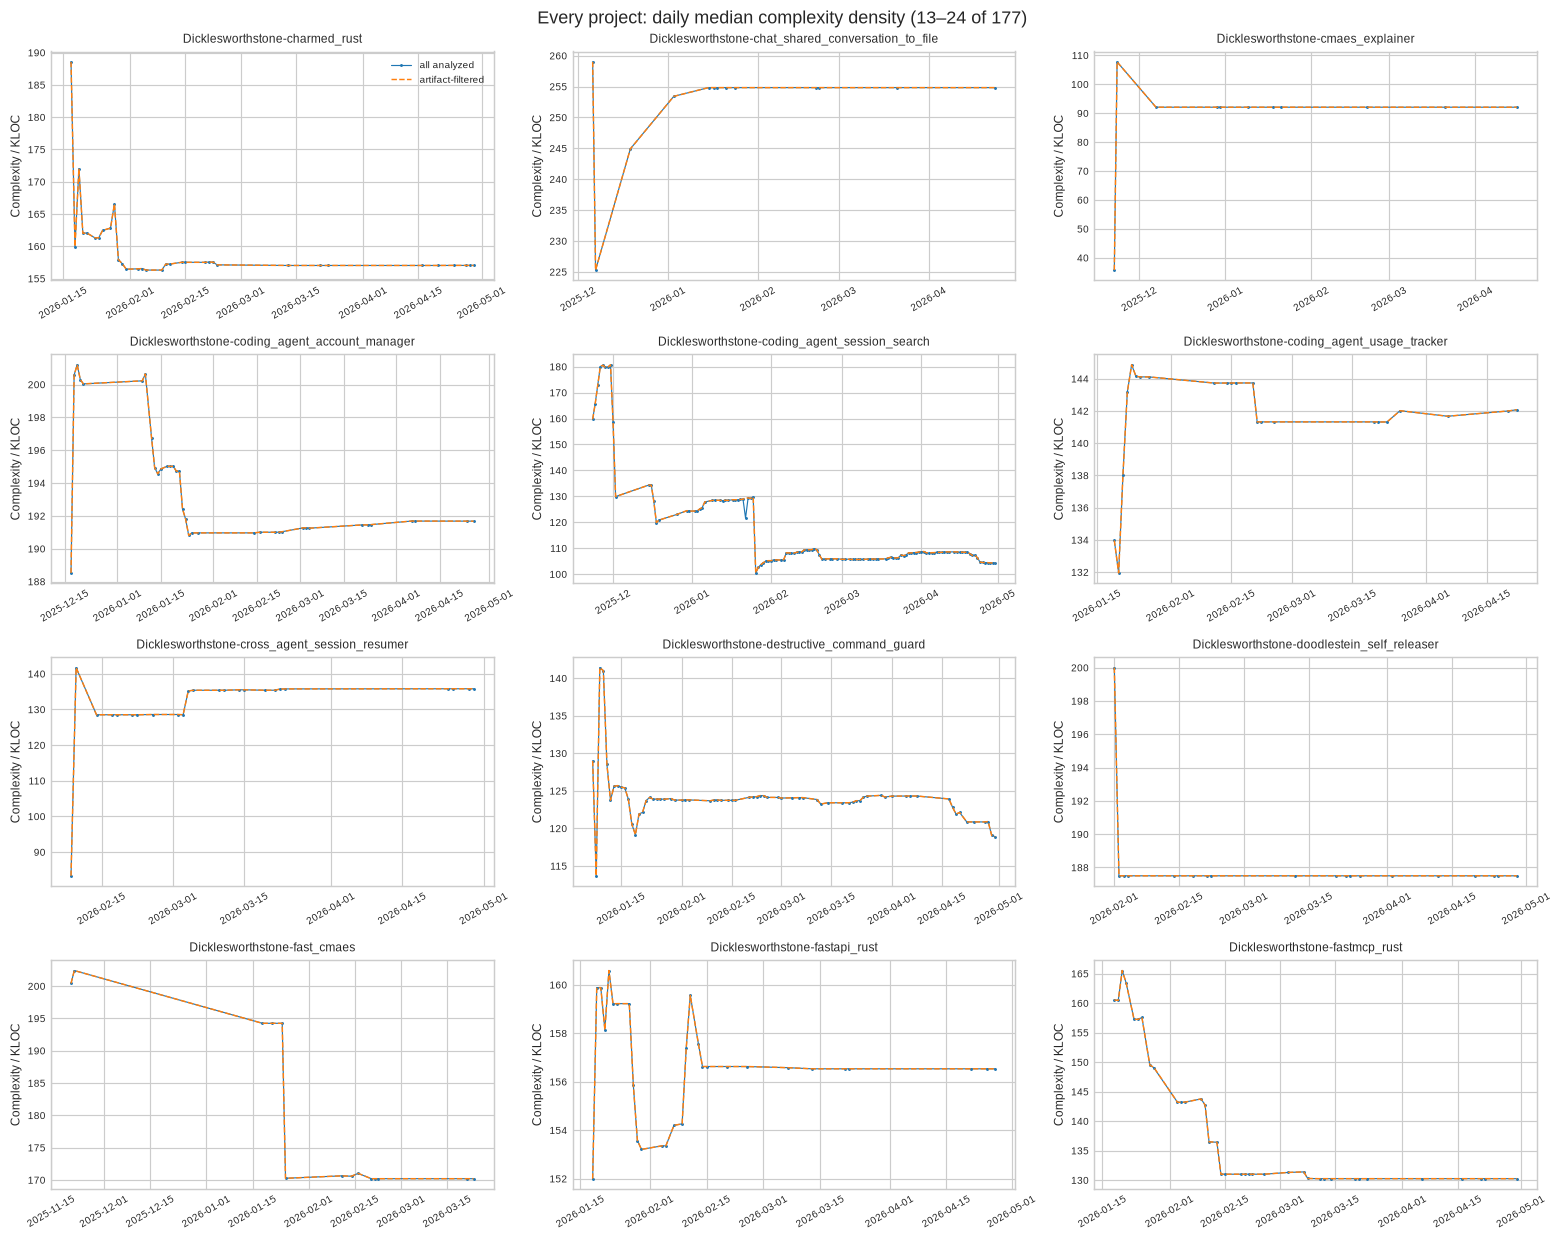

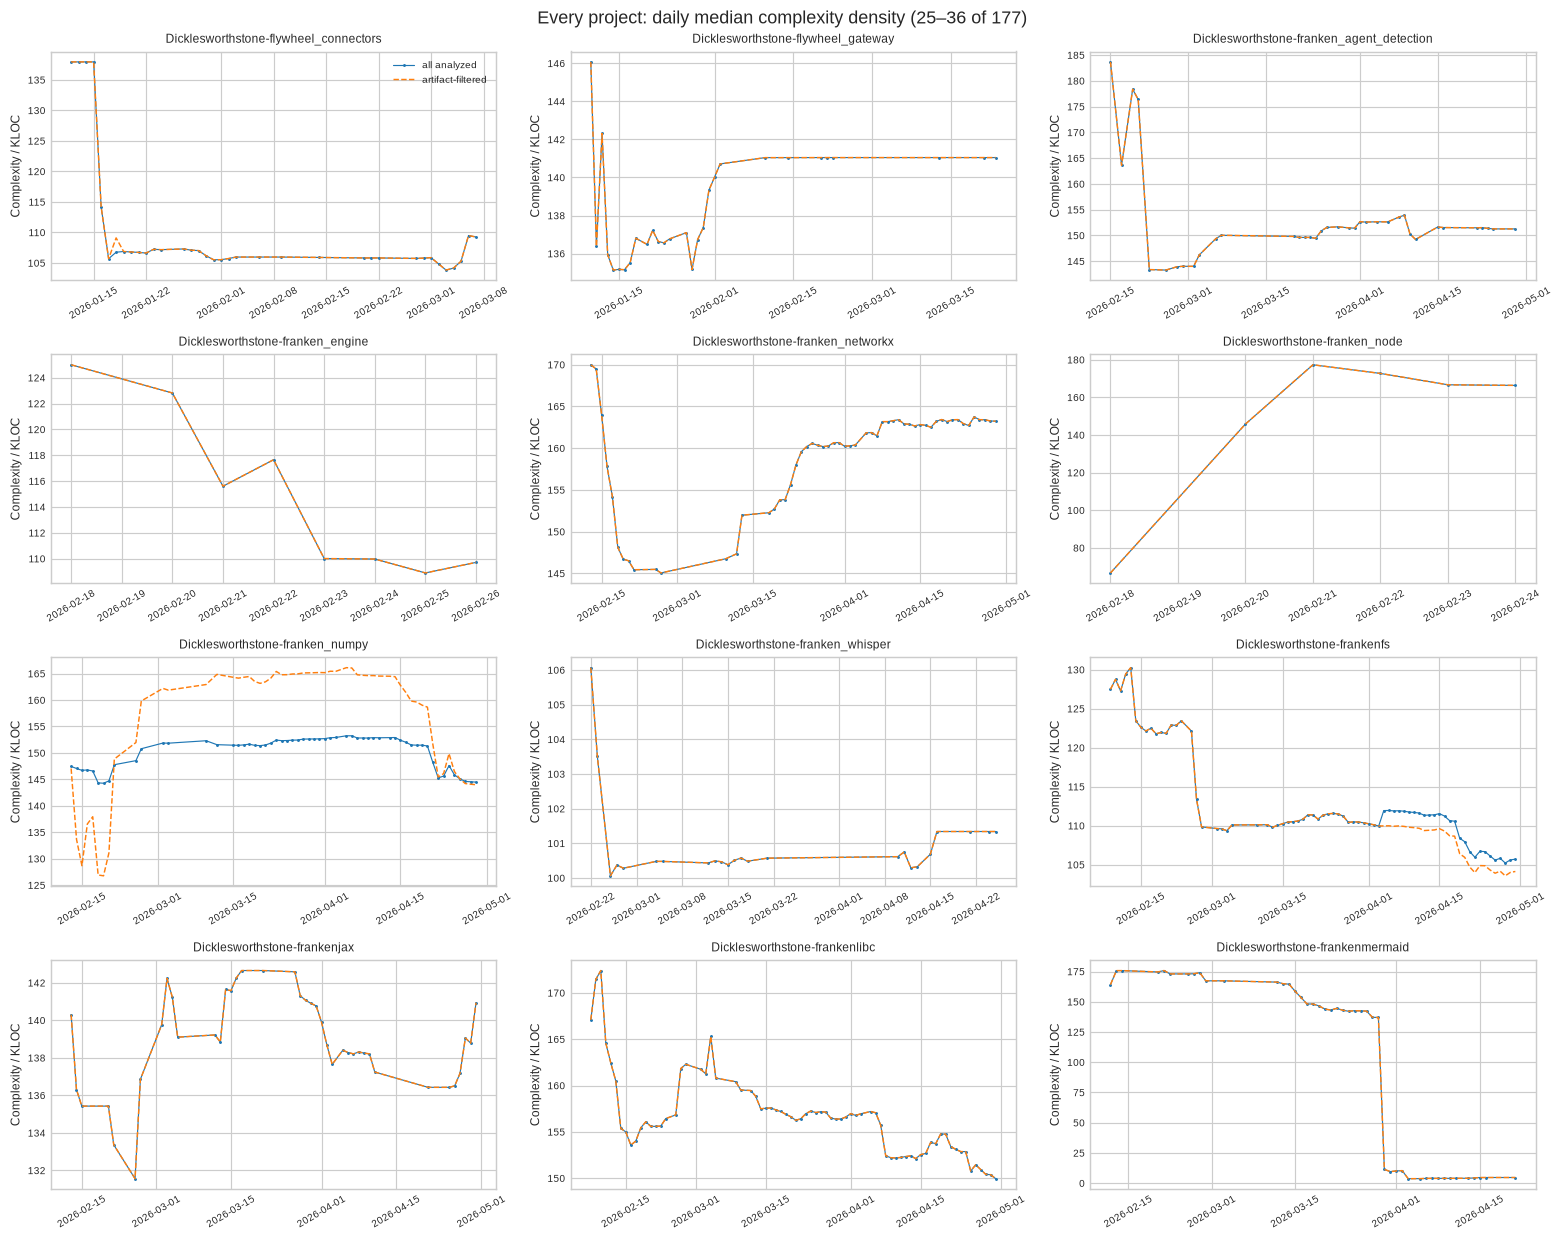

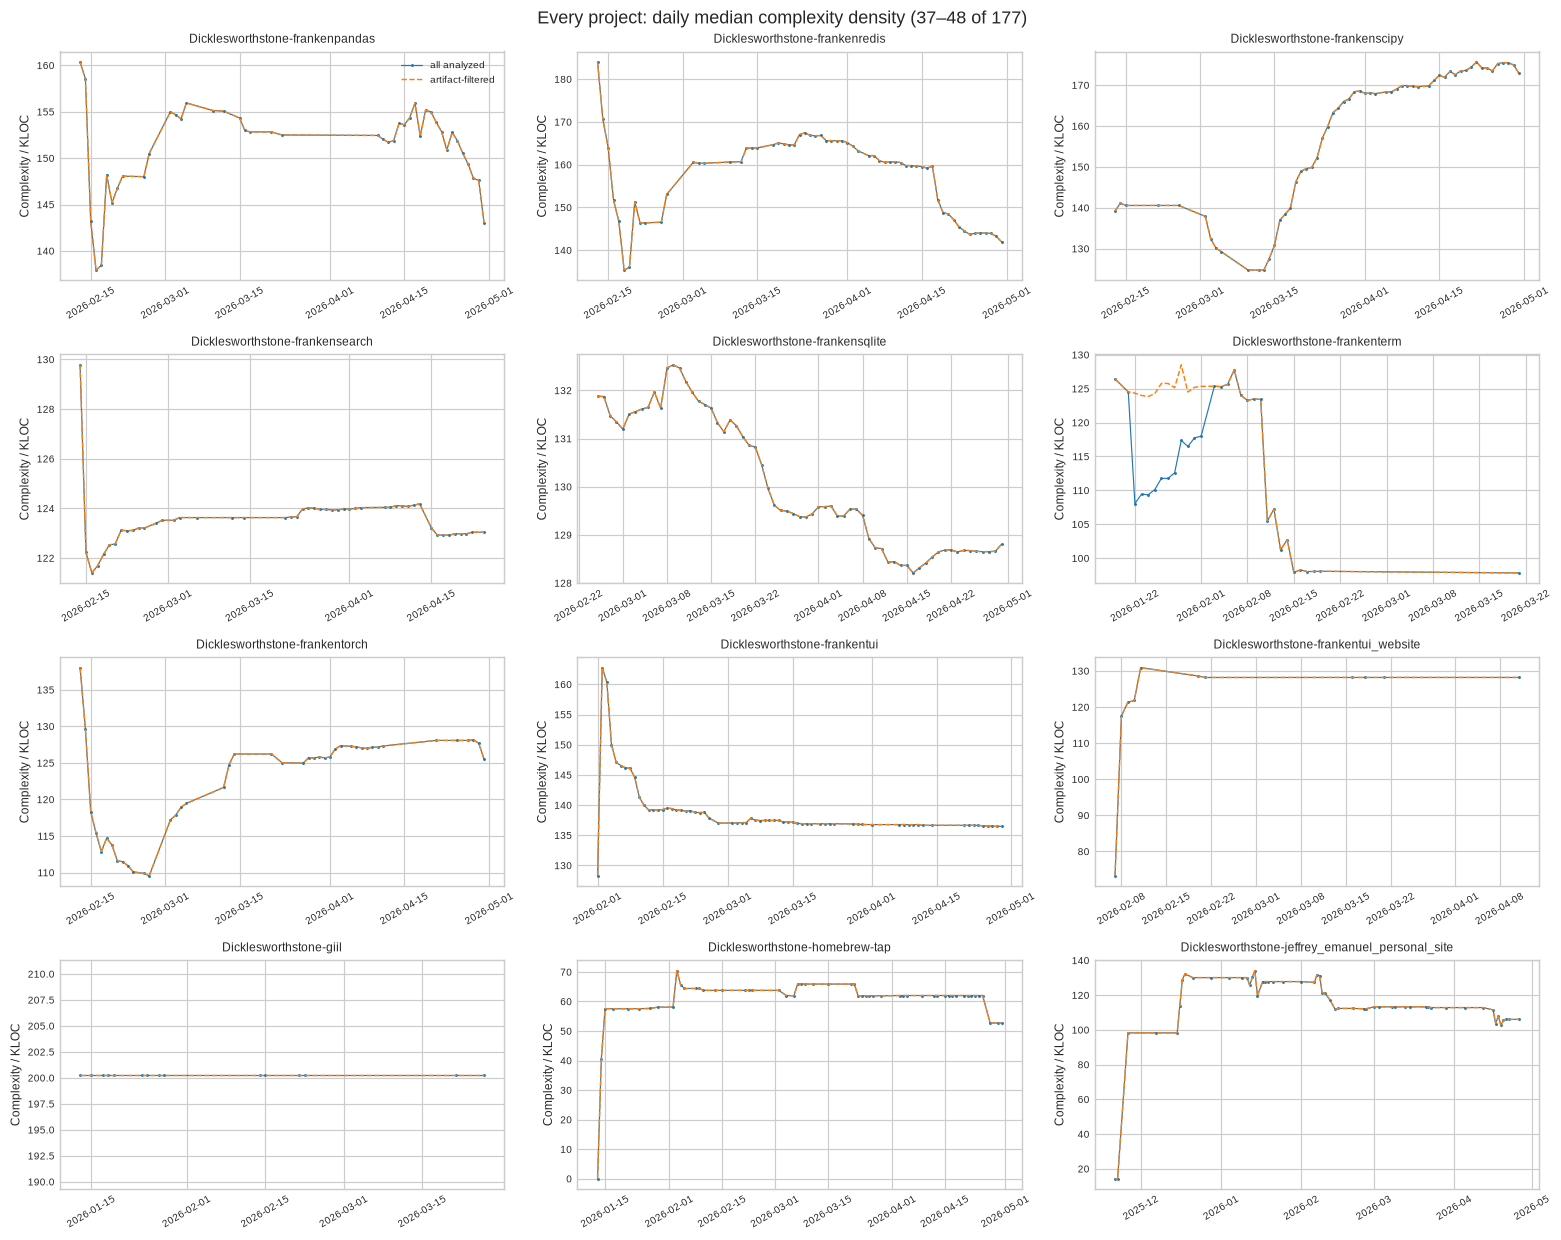

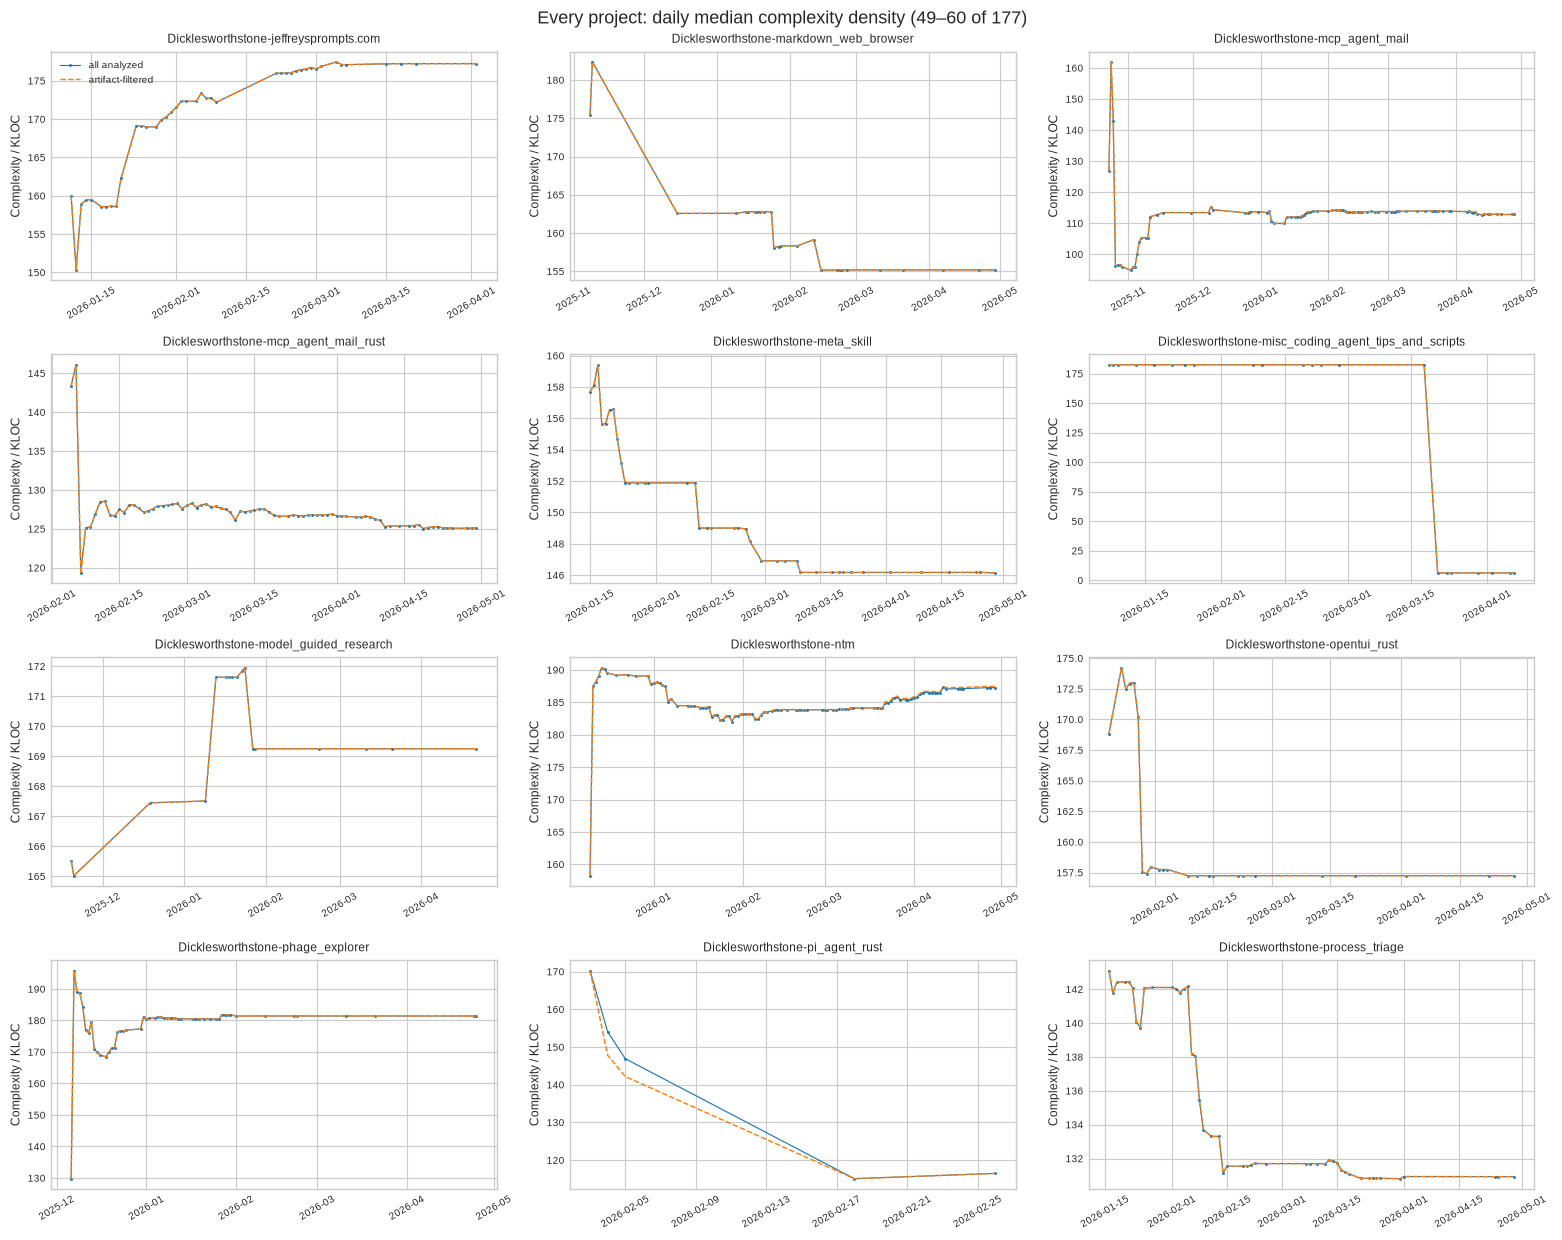

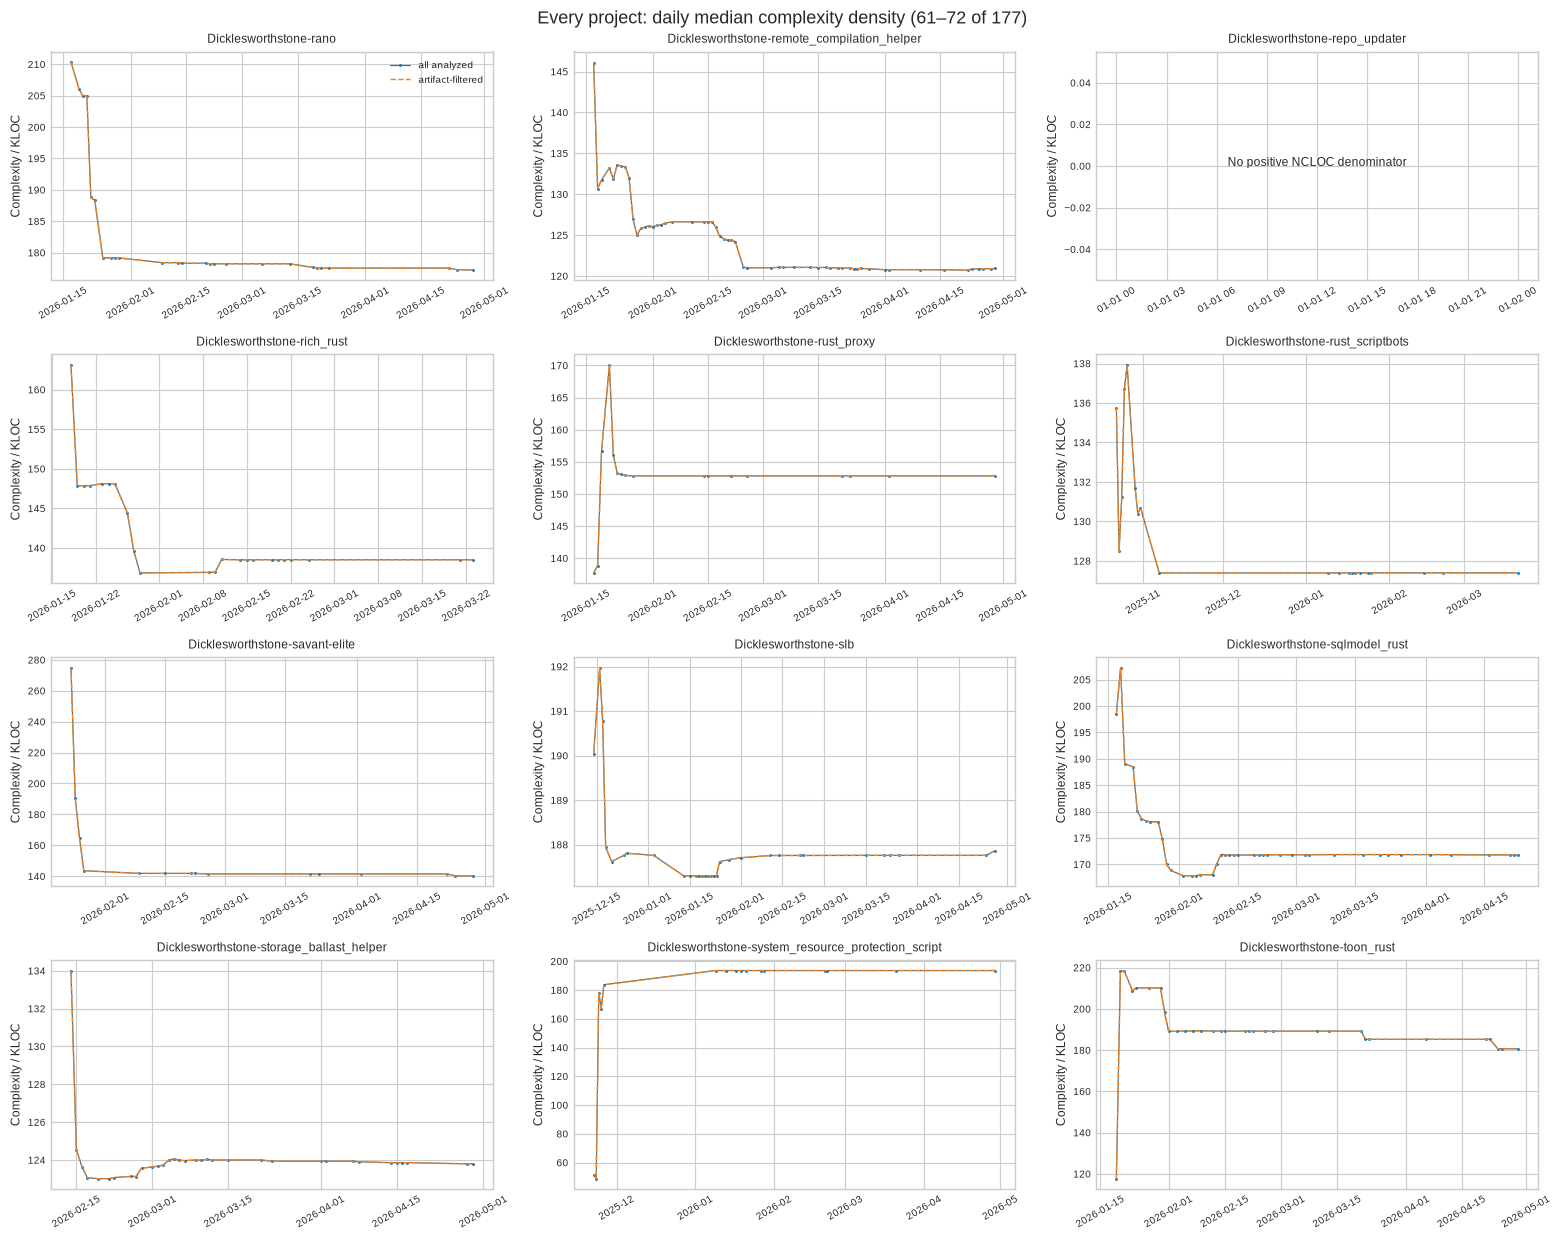

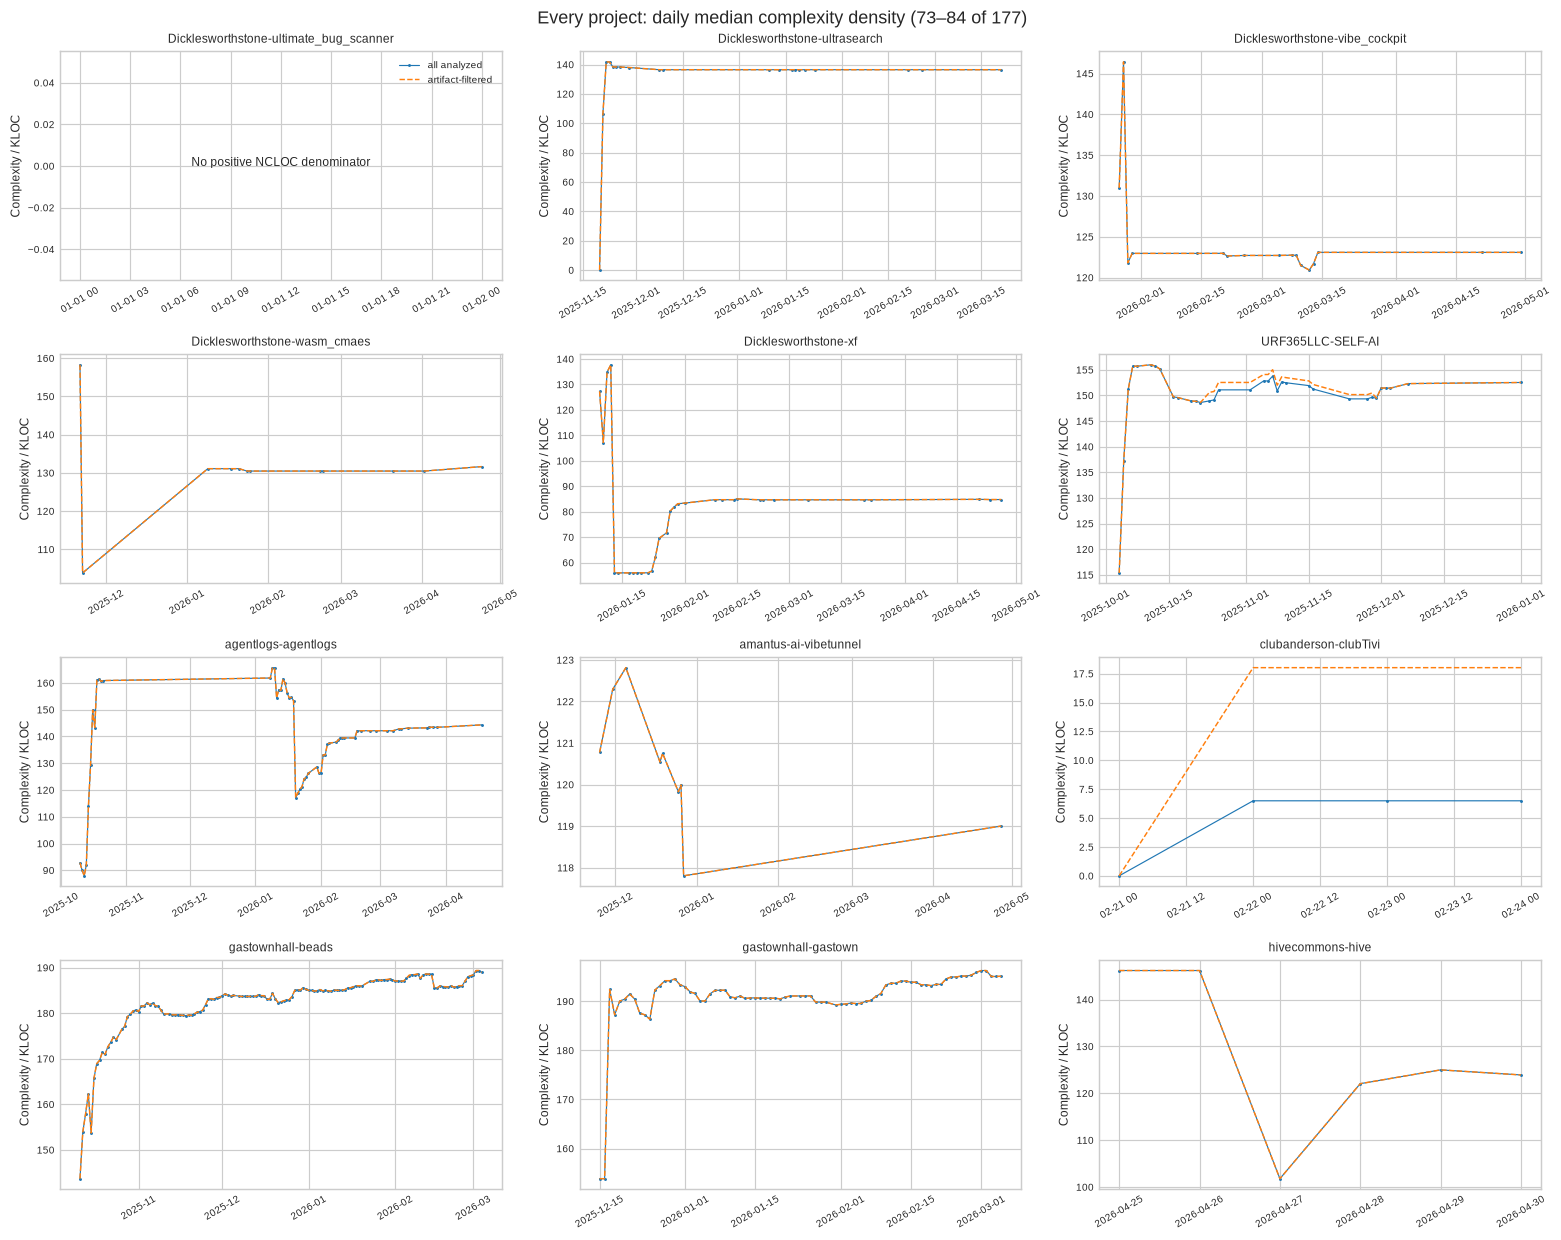

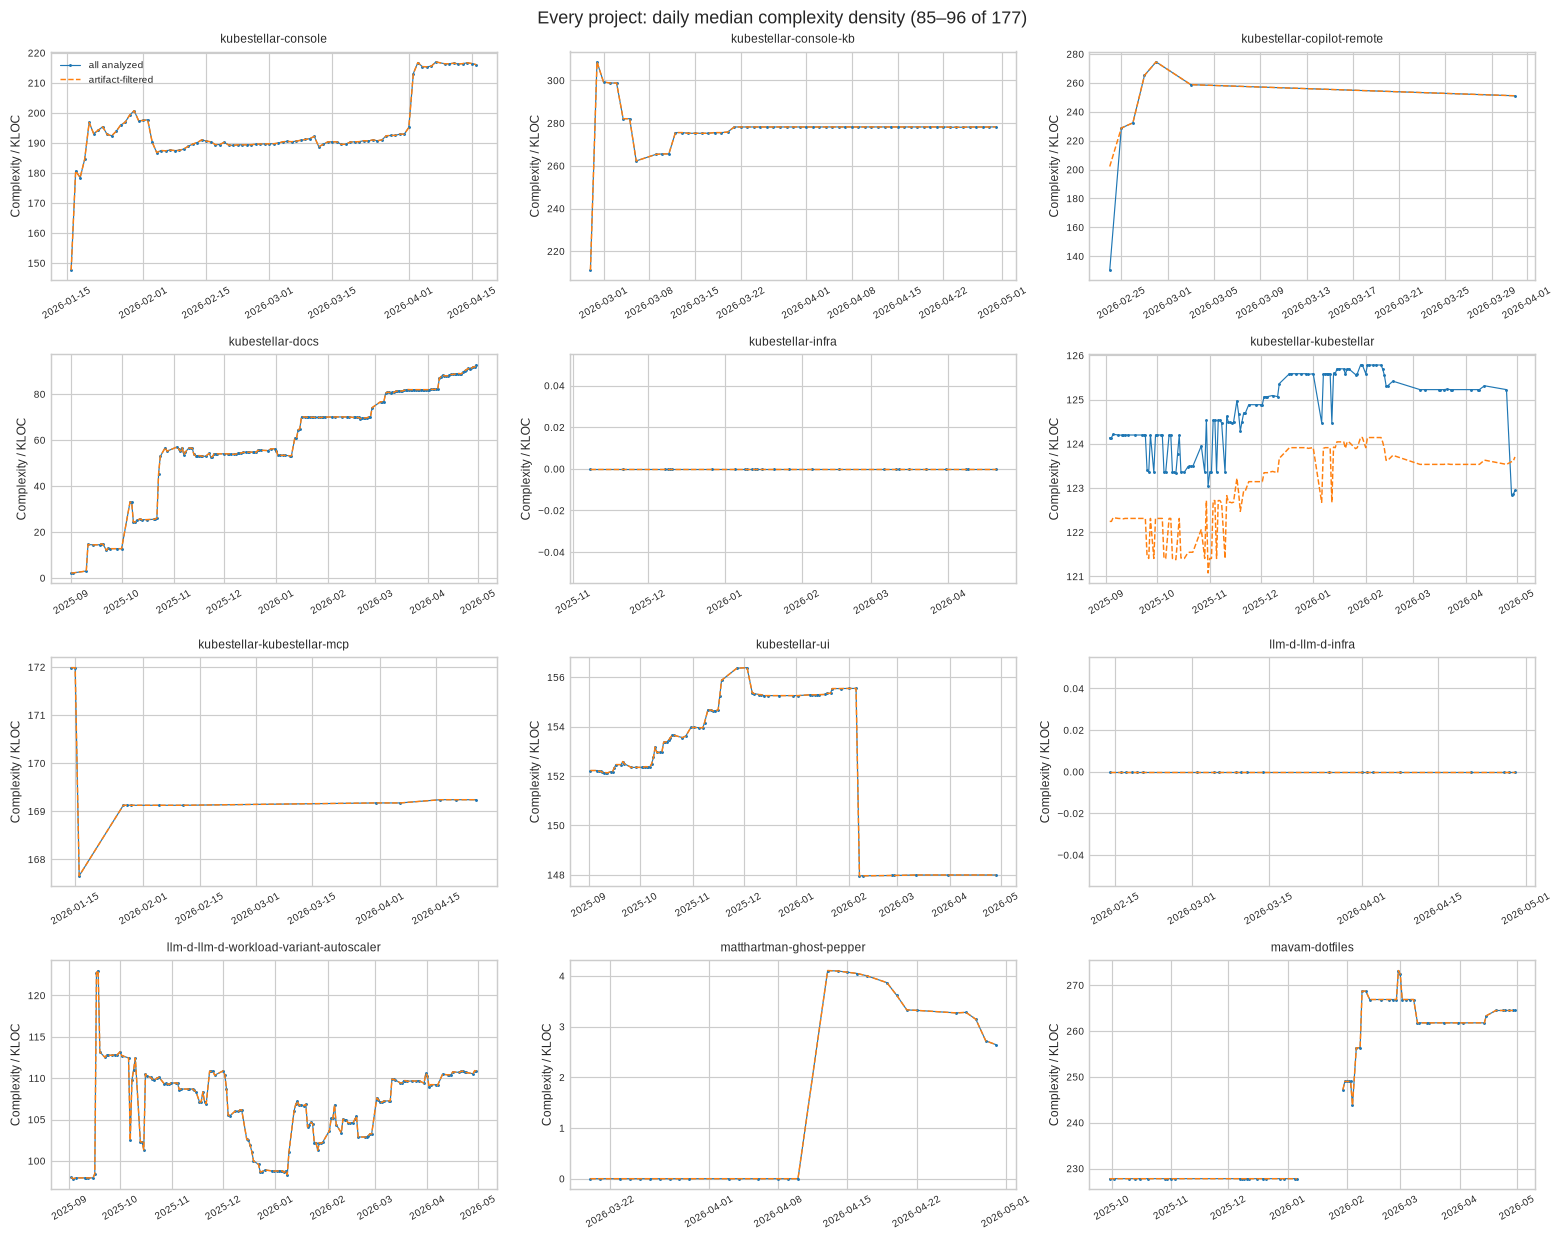

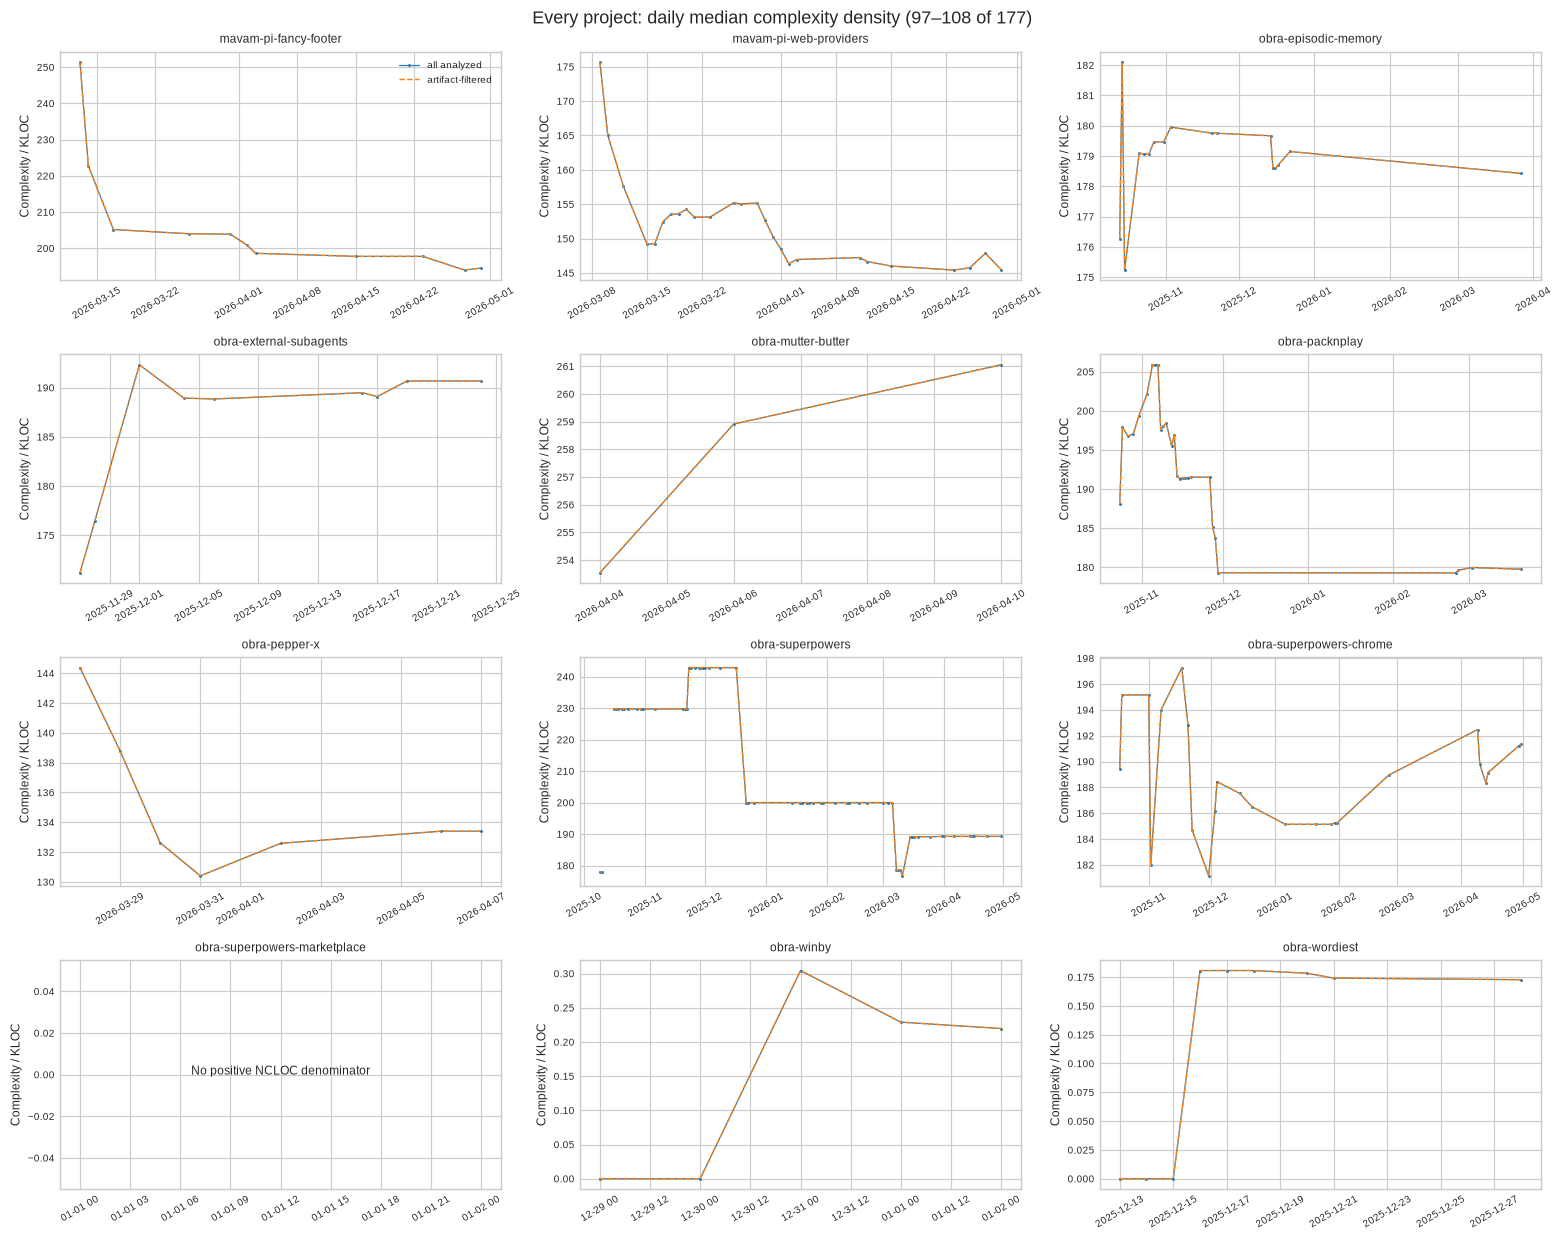

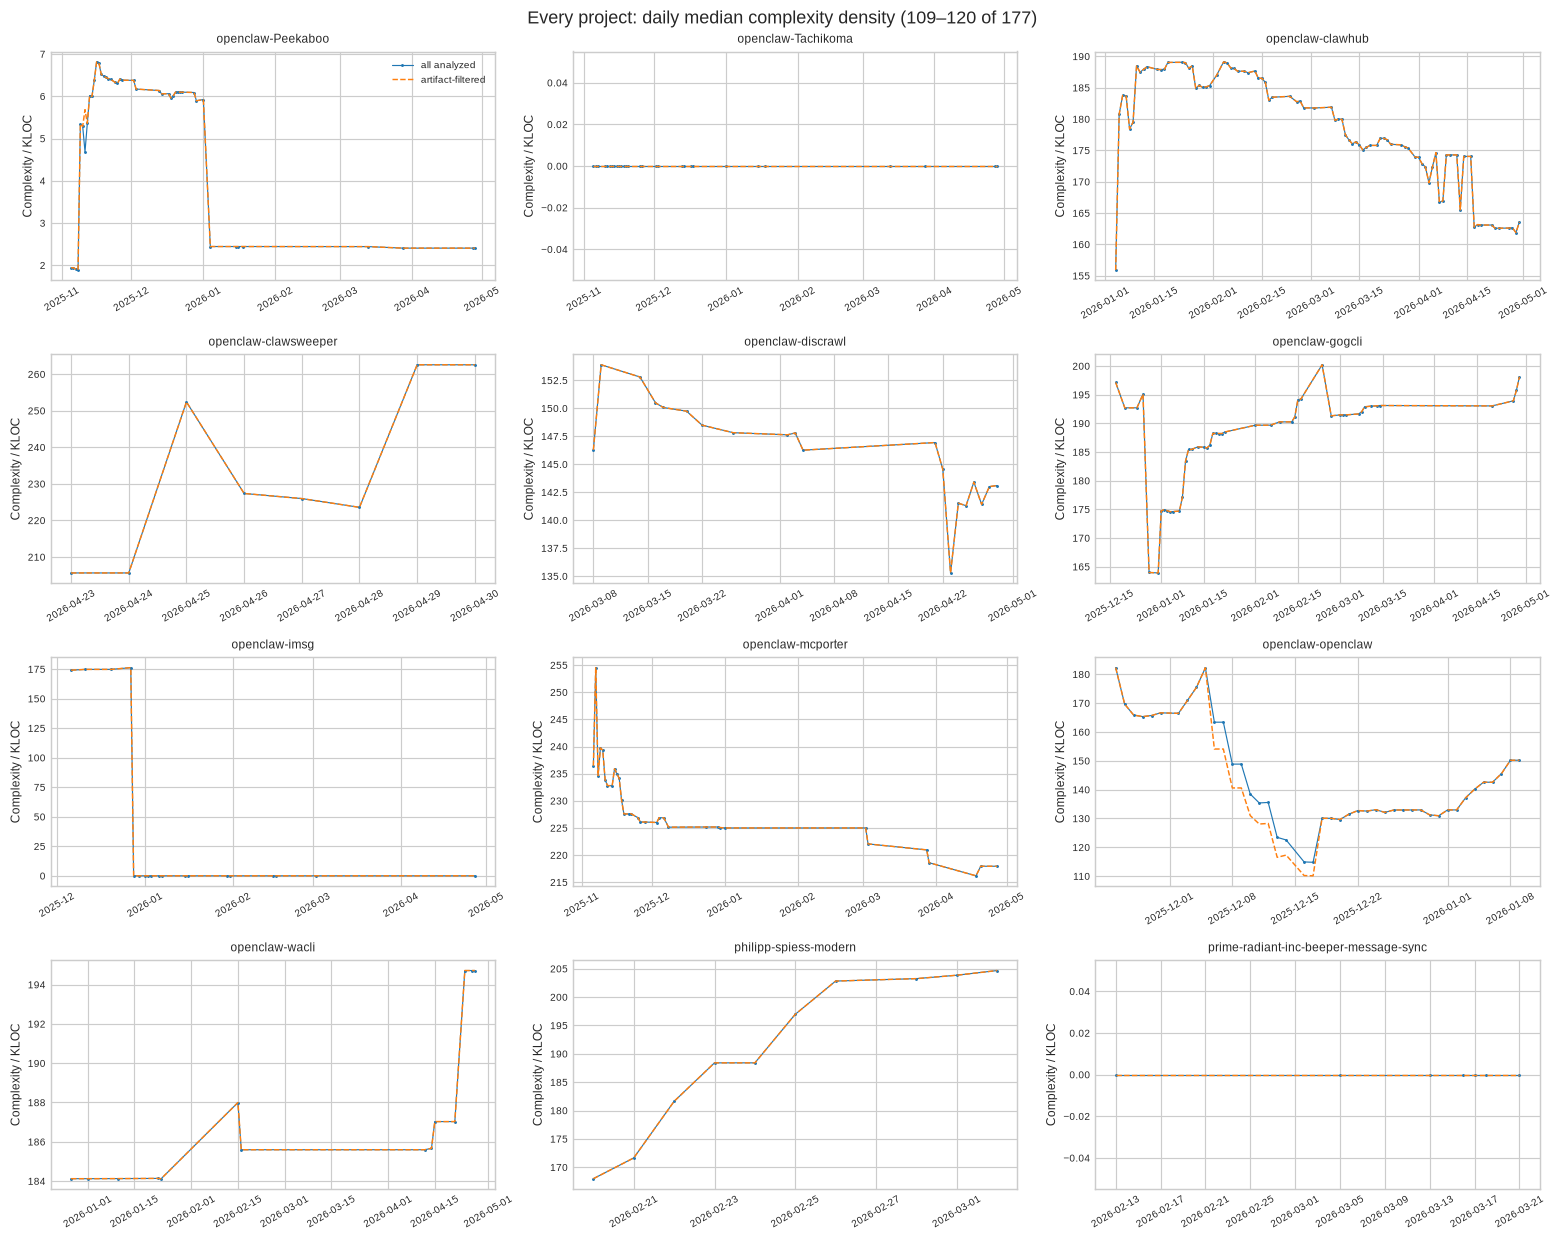

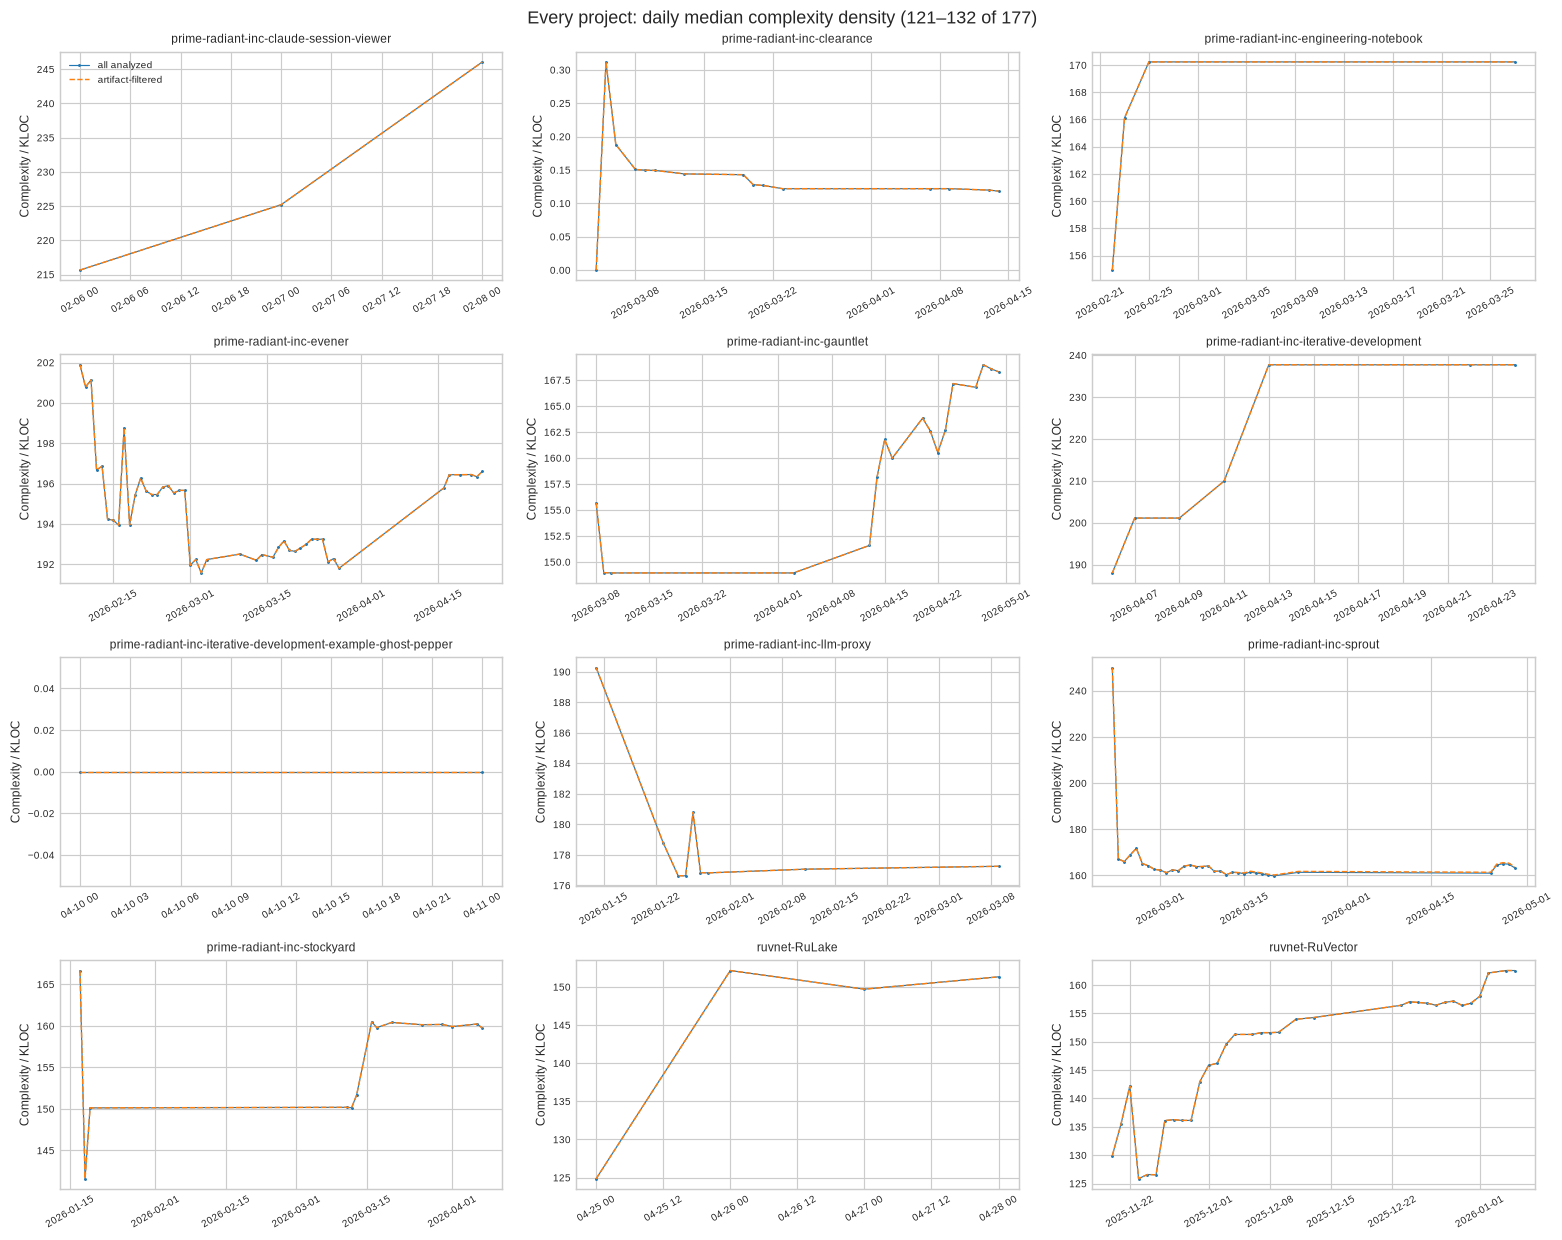

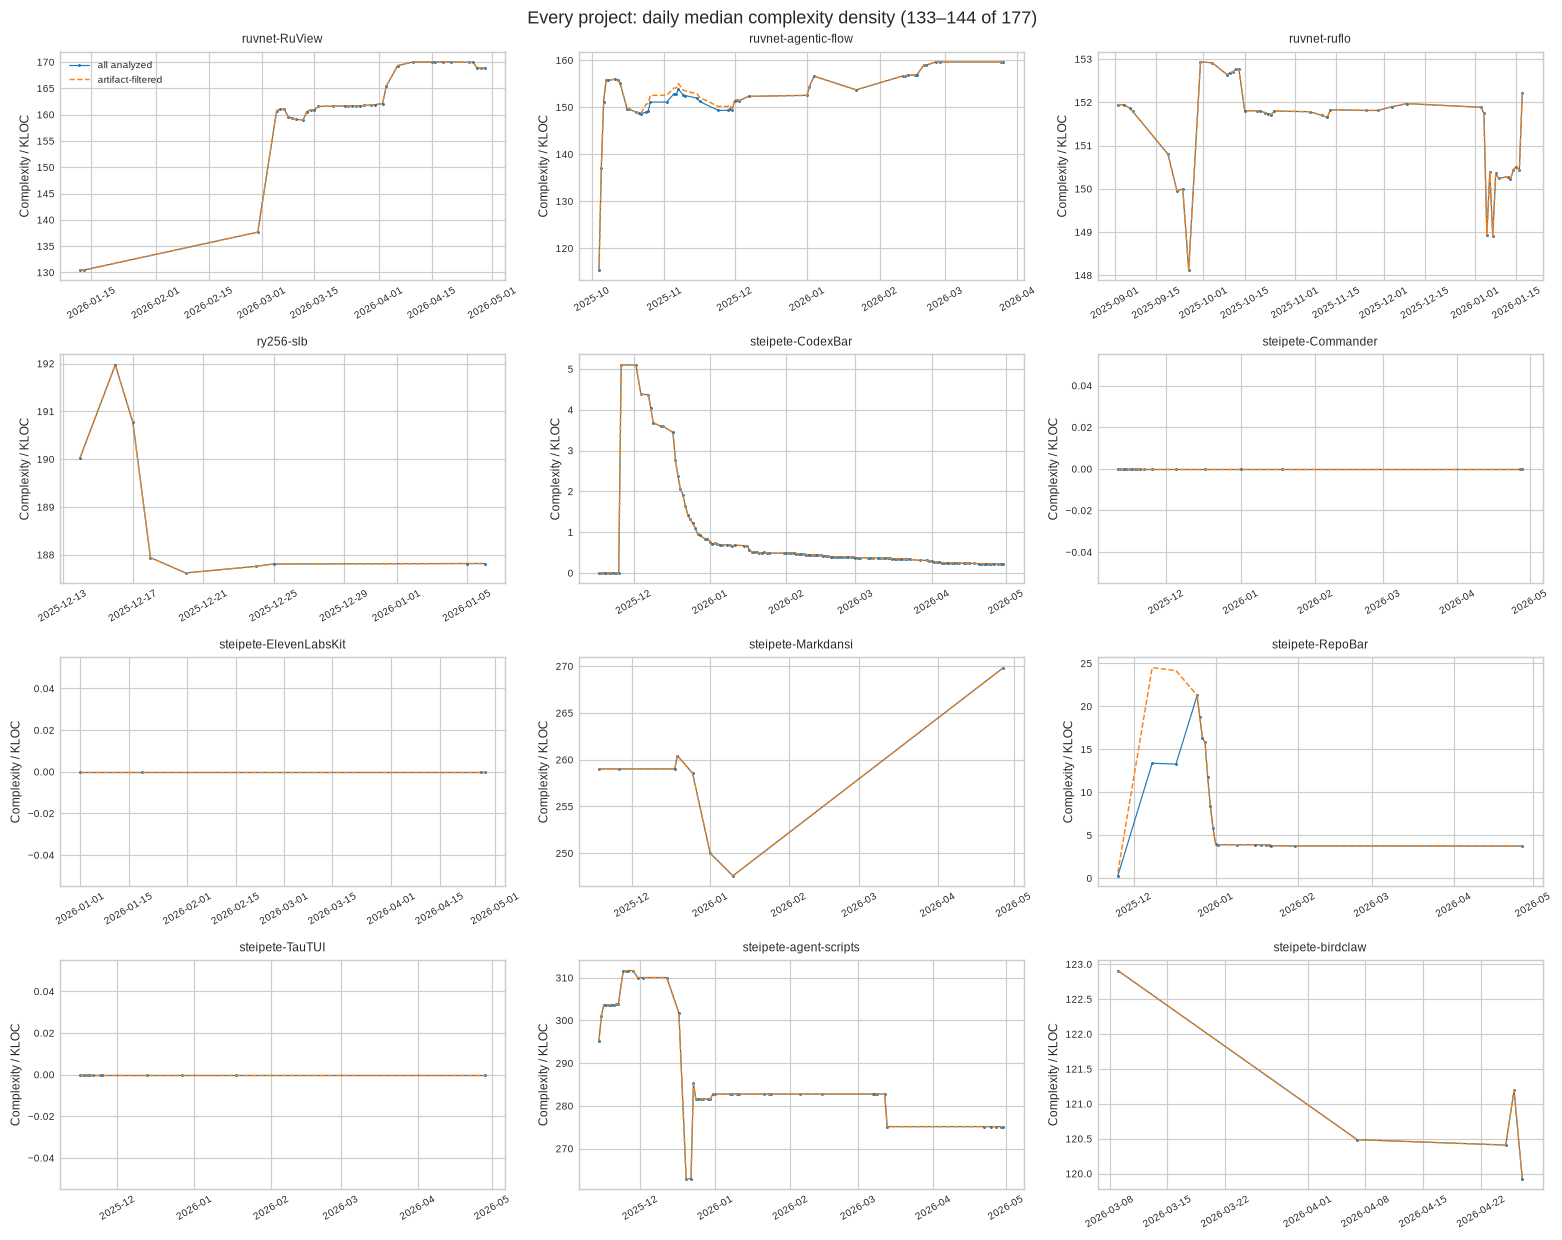

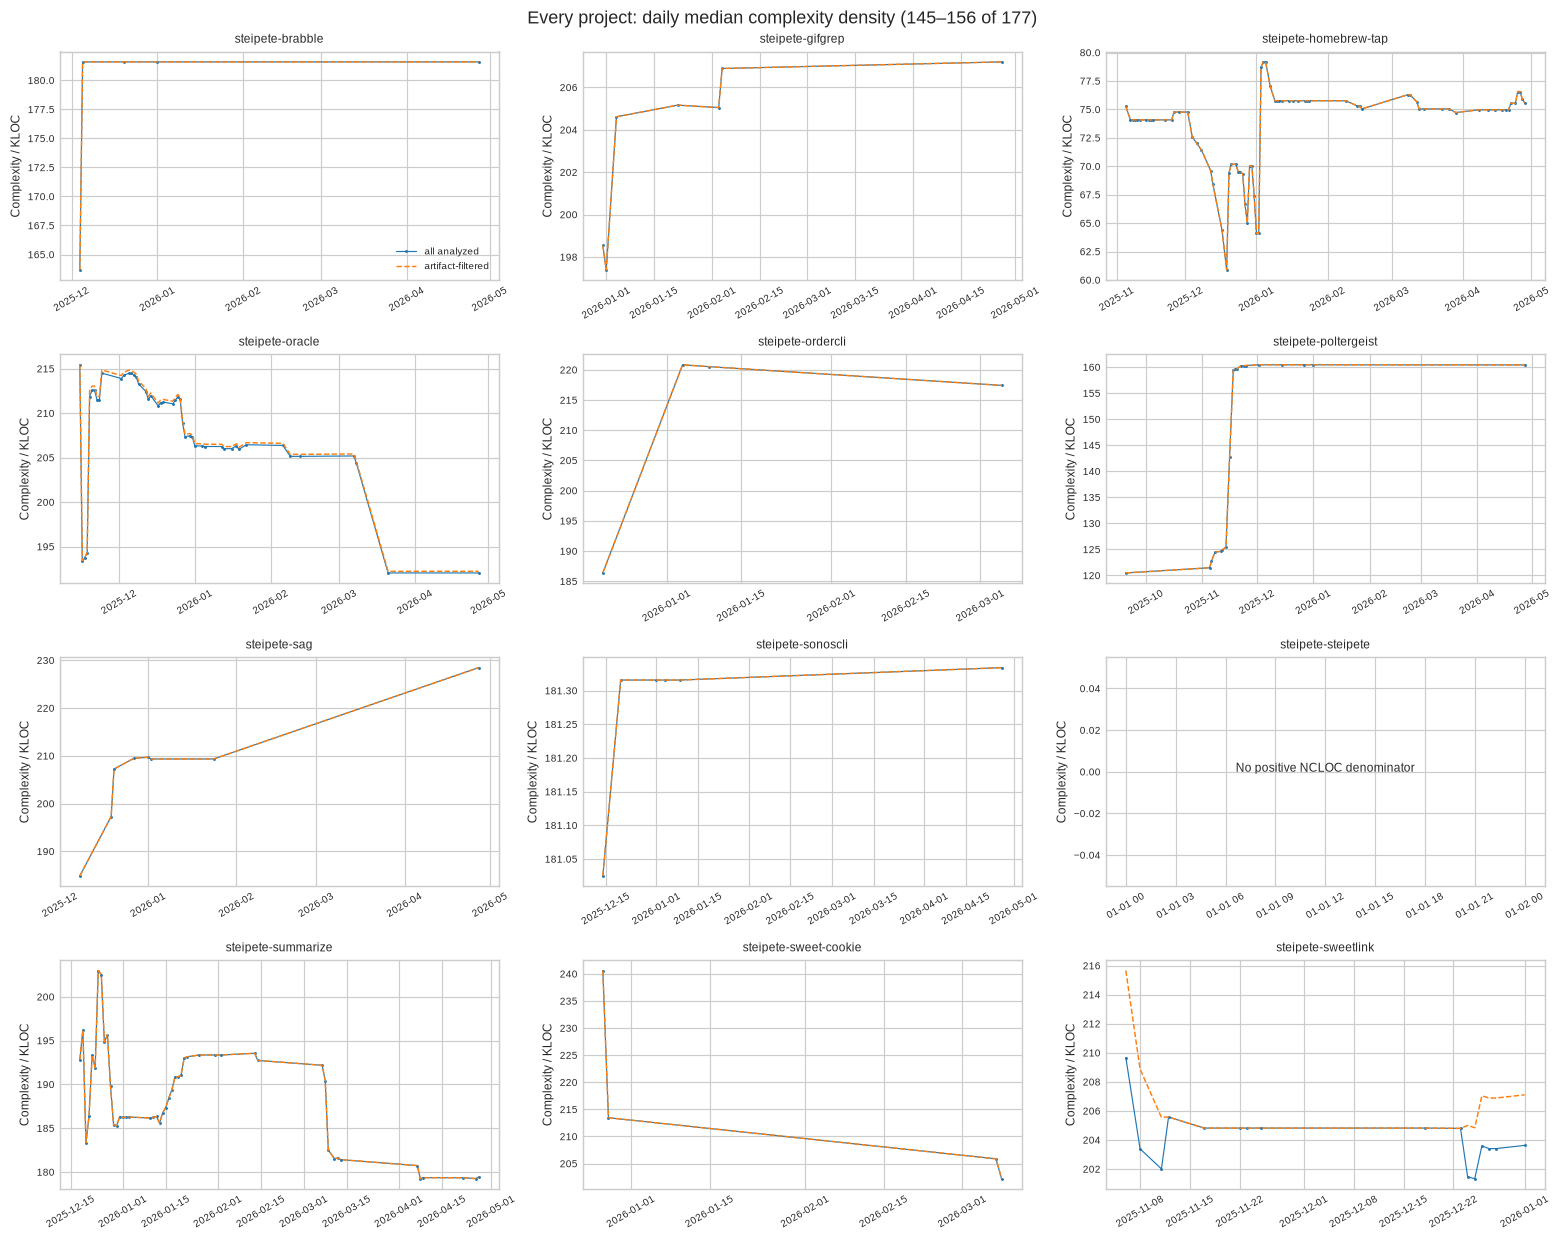

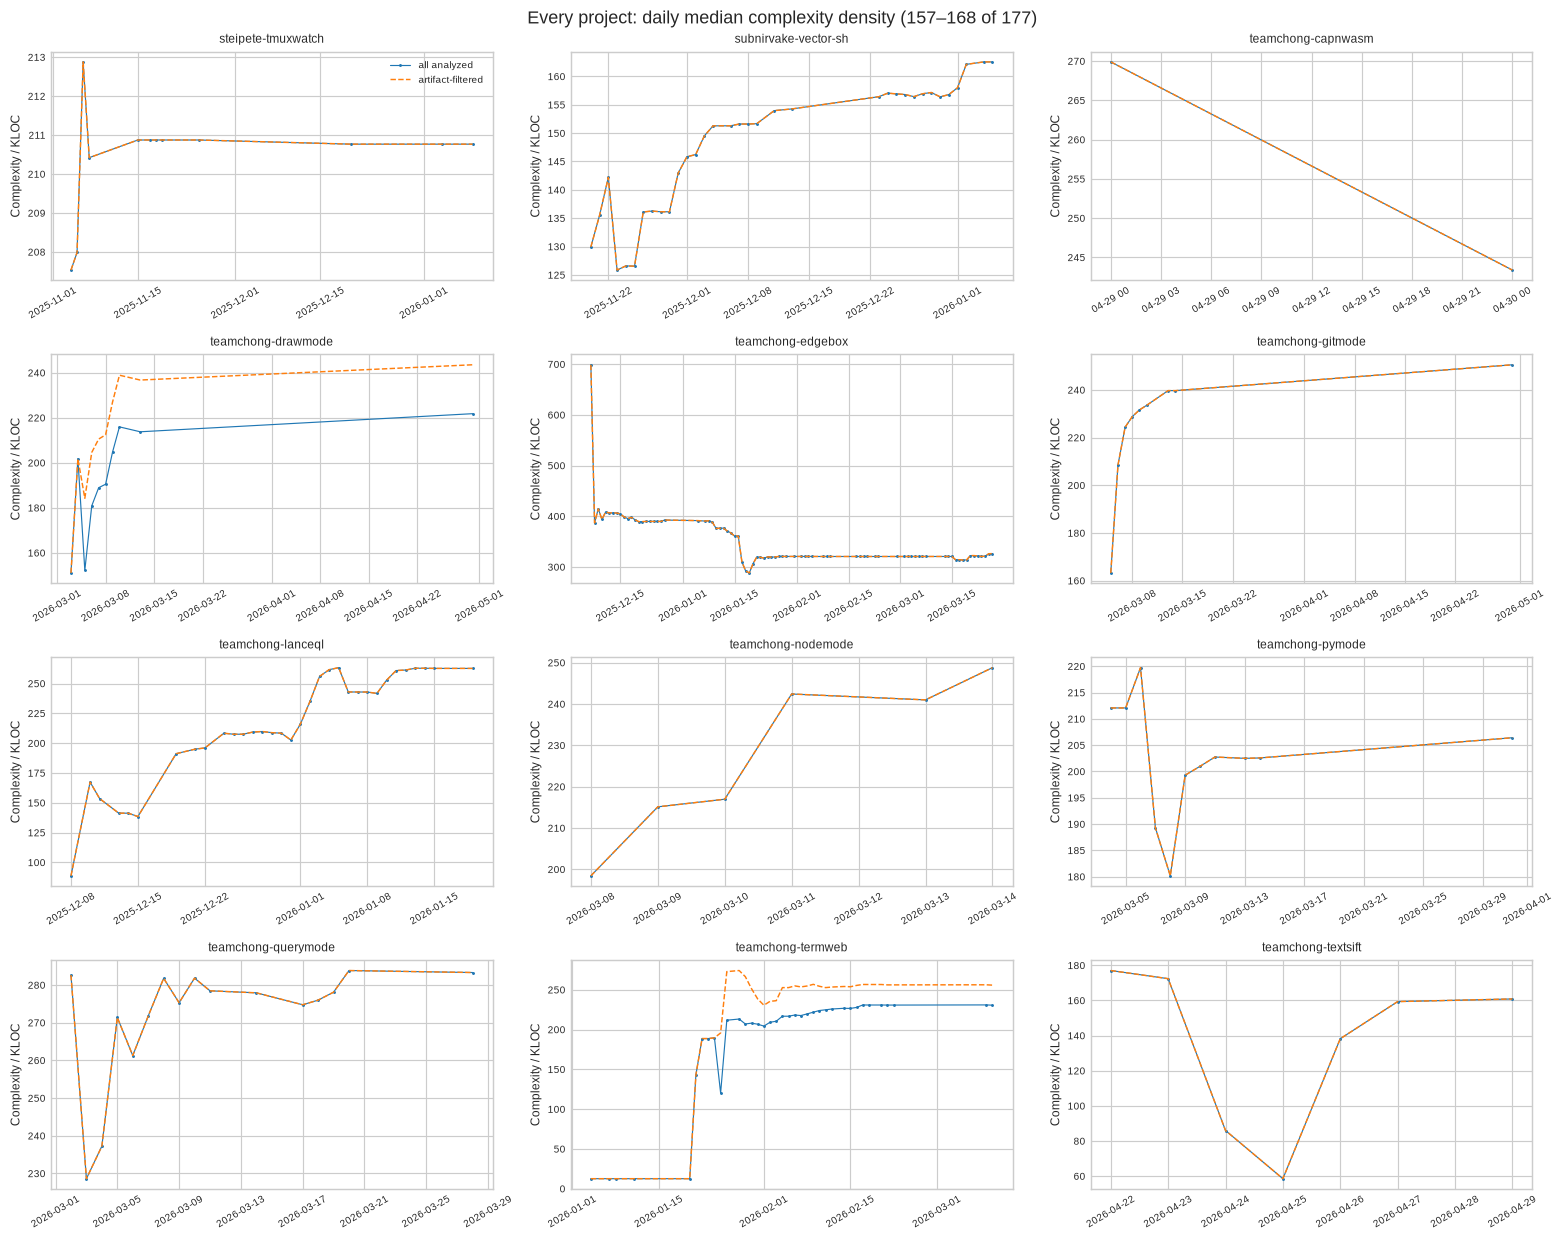

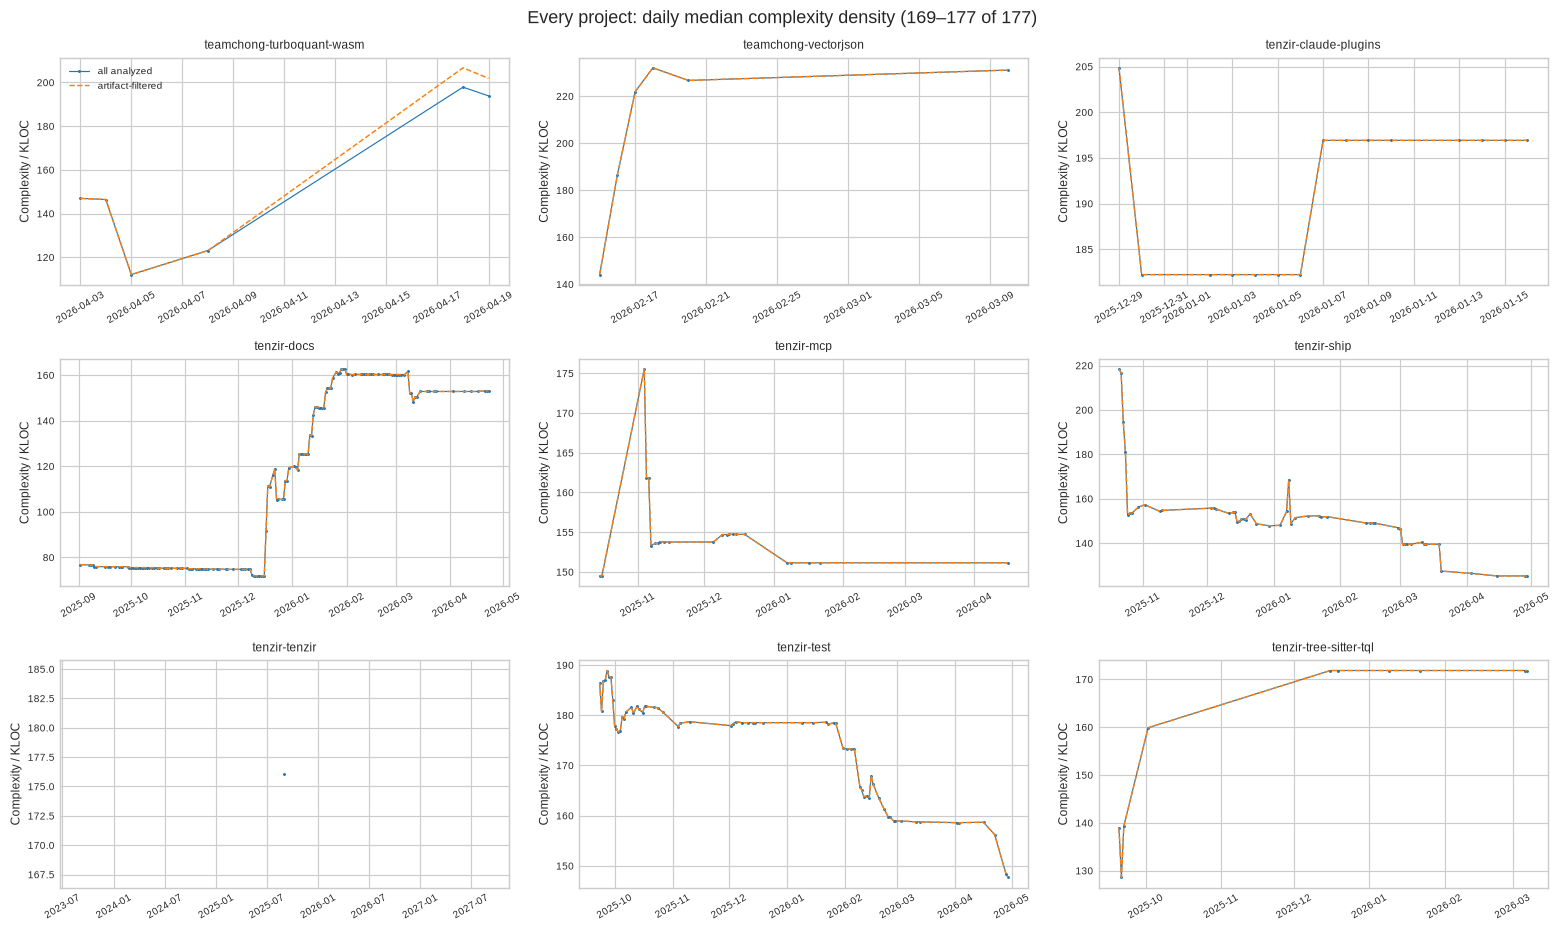

metric,cognitive_per_kloc,complexity_per_kloc,function_p95,violations_per_kloc
project,,,,
Dicklesworthstone-aadc,-99.082270,-60.831020,-2.740000e+01,-1.472175
Dicklesworthstone-acip,NaN,NaN,NaN,NaN
Dicklesworthstone-agentic_coding_flywheel_setup,6.815681,12.914089,3.500500e+02,-1.011514
Dicklesworthstone-asupersync,35.972050,-56.179974,3.660000e+01,0.974674
Dicklesworthstone-asupersync_ansi_c,-54.039778,54.340178,3.300000e+01,-5.559420
Dicklesworthstone-automated_plan_reviser_pro,NaN,NaN,NaN,NaN
Dicklesworthstone-beads_rust,-13.952265,-13.309975,3.000000e+00,-0.510186
Dicklesworthstone-beads_viewer,-62.086363,-29.274694,-1.280000e+01,0.220516
Dicklesworthstone-beads_viewer_rust,-13.702767,-11.831521,-1.975000e+01,1.616923


Endpoint deltas use the first and last **nonmissing daily value for that metric**; their dates and observation counts are in `project_endpoints.csv`. Different projects/metrics can span different periods. Fewer than two valid days yields no delta; Spearman time-rank correlations require at least three valid days and are descriptive only. These are not fixed-window treatment effects.

In [6]:
rq4.trajectory_pages(daily, OUTPUT_DIR, show=SHOW_ALL_PROJECT_PAGES)
endpoint_synopsis = endpoints[endpoints.metric.isin(trend_metrics)].pivot(index="project", columns="metric", values="delta")
endpoint_synopsis = endpoint_synopsis.reindex(inventory.index)
show_all(endpoint_synopsis)
display(Markdown(
    "Endpoint deltas use the first and last **nonmissing daily value for that metric**; "
    "their dates and observation counts are in `project_endpoints.csv`. Different "
    "projects/metrics can span different periods. Fewer than two valid days yields "
    "no delta; Spearman time-rank correlations require at least three valid days "
    "and are descriptive only. These are not fixed-window treatment effects."
))


## 7. Artifact sensitivity, static test paths and hotspot concentration

These comparisons give each project one latest-day value. The path heuristic is
deliberately visible in `rq4_analysis.py`; a generated knowledge base may itself
be the product. Review inclusion rules per project before choosing a primary
analysis. Static test-path share refers to analyzed file NCLOC, not test coverage.
The top-ten complexity share depends on project size and includes all analyzed
files. Separate source-filtered complexity and function tails are available for
all sampled dates in the exported panel.


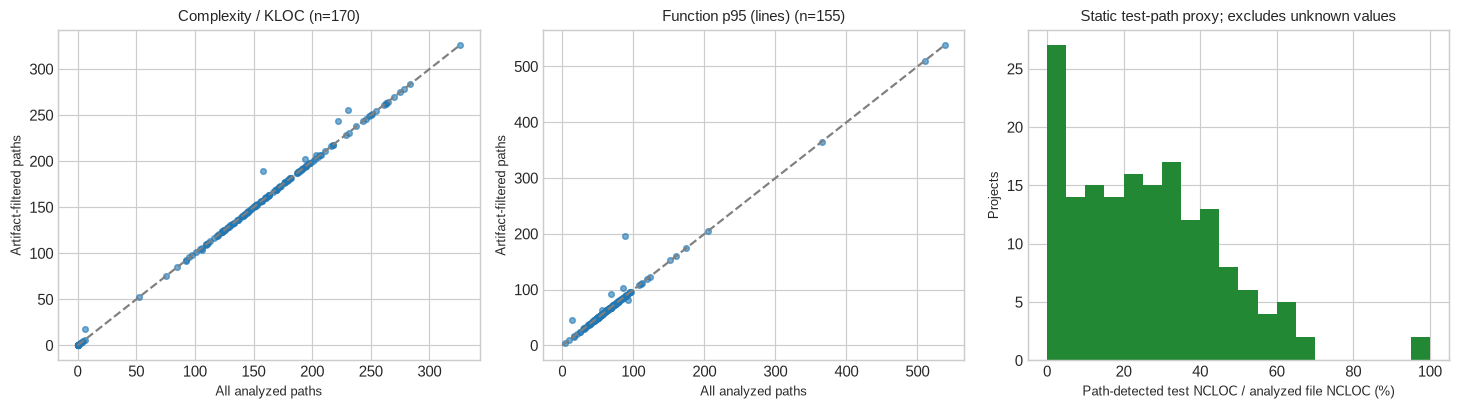

,ncloc,source_ncloc,artifact_ncloc_share,complexity_per_kloc,source_complexity_per_kloc,function_p95,source_function_p95,test_path_ncloc_share,top10_complexity_share
project,,,,,,,,,
tenzir-tenzir,4146.0,4146.0,0.000000,176.073324,176.073324,30.00,30.00,34.732272,81.095890
Dicklesworthstone-ultimate_bug_scanner,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
obra-external-subagents,7290.0,7290.0,0.000000,190.672154,190.672154,29.70,29.70,35.020576,62.805755
obra-wordiest,5789.0,5789.0,0.000000,0.172741,0.172741,NaN,NaN,17.049577,100.000000
URF365LLC-SELF-AI,254108.0,254108.0,0.000000,152.521762,152.521762,68.00,68.00,26.319518,6.298217
steipete-sweetlink,19767.0,19430.0,1.704862,203.622199,207.102419,46.15,46.15,25.330096,42.409938
obra-winby,4554.0,4554.0,0.000000,0.219587,0.219587,NaN,NaN,0.000000,100.000000
subnirvake-vector-sh,627586.0,627586.0,0.000000,162.556207,162.556207,50.00,50.00,9.002113,6.641965
ruvnet-RuVector,627586.0,627586.0,0.000000,162.556207,162.556207,50.00,50.00,9.002113,6.641965


In [7]:
sensitivity_cols = ["ncloc", "source_ncloc", "artifact_ncloc_share", "complexity_per_kloc", "source_complexity_per_kloc", "function_p95", "source_function_p95", "test_path_ncloc_share", "top10_complexity_share"]
sensitivity = latest_daily[sensitivity_cols]
export_table(sensitivity, "latest_artifact_sensitivity", index=True)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, raw, filtered, title in [
    (axes[0], "complexity_per_kloc", "source_complexity_per_kloc", "Complexity / KLOC"),
    (axes[1], "function_p95", "source_function_p95", "Function p95 (lines)"),
]:
    points = sensitivity[[raw, filtered]].dropna()
    ax.scatter(points[raw], points[filtered], s=15, alpha=.6)
    if not points.empty:
        upper = points.max().max()
        ax.plot([0, upper], [0, upper], color="gray", ls="--")
    ax.set_xlabel("All analyzed paths")
    ax.set_ylabel("Artifact-filtered paths")
    ax.set_title(f"{title} (n={len(points)})")
axes[2].hist(sensitivity.test_path_ncloc_share.dropna(), bins=20, color="#228833")
axes[2].set_xlabel("Path-detected test NCLOC / analyzed file NCLOC (%)")
axes[2].set_ylabel("Projects")
axes[2].set_title("Static test-path proxy; excludes unknown values")
finish_figure(fig, "artifact_and_test_path_sensitivity")
show_all(sensitivity)
export_table(details["hotspots"], "latest_source_like_hotspots")


## 8. Detailed issue composition and quality-gate conditions

Only exported rows at a unique latest snapshot are counted, once per selected
snapshot. These plots do not claim issue-export completeness or unique issues
across repositories. Missing details are not assigned zero defects. Rules and
severity depend on analyzer/language/profile; “legacy” severity and newer impact
categories should not be combined as separate issues. Gate failure means a
configured condition failed and may reflect unimported coverage.


severity,BLOCKER,CRITICAL,MAJOR,MINOR,INFO
project,,,,,
Dicklesworthstone-aadc,0,10,0,0,0
Dicklesworthstone-asupersync,1,89,10,10,0
Dicklesworthstone-asupersync_ansi_c,0,10,0,4,0
Dicklesworthstone-beads_rust,1,103,0,0,0
Dicklesworthstone-beads_viewer,2,401,68,147,4
Dicklesworthstone-beads_viewer_rust,2,102,60,131,0
Dicklesworthstone-bio_inspired_nanochat,1,65,59,200,10
Dicklesworthstone-brenner_bot,3,212,627,1995,5
Dicklesworthstone-cass_memory_system,1,134,191,817,0


exported_rows
rule_source rule  severity               
python      S117  MINOR              1563
rust        S3776 CRITICAL           1540
python      S3776 CRITICAL            951
            S1192 CRITICAL            667
typescript  S7778 MINOR               598
go          S3776 CRITICAL            594
typescript  S6759 MINOR               587
            S4325 MINOR               450
python      S1172 MAJOR               446
typescript  S7764 MINOR               445
            S3776 CRITICAL            299
python      S1481 MINOR               295
typescript  S3358 MAJOR               252
go          S1192 CRITICAL            239
typescript  S7748 MINOR               199
javascript  S7764 MINOR               184
typescript  S6747 MAJOR               174
            S1128 MINOR               167
            S6594 MINOR               148
            S7773 MINOR               145

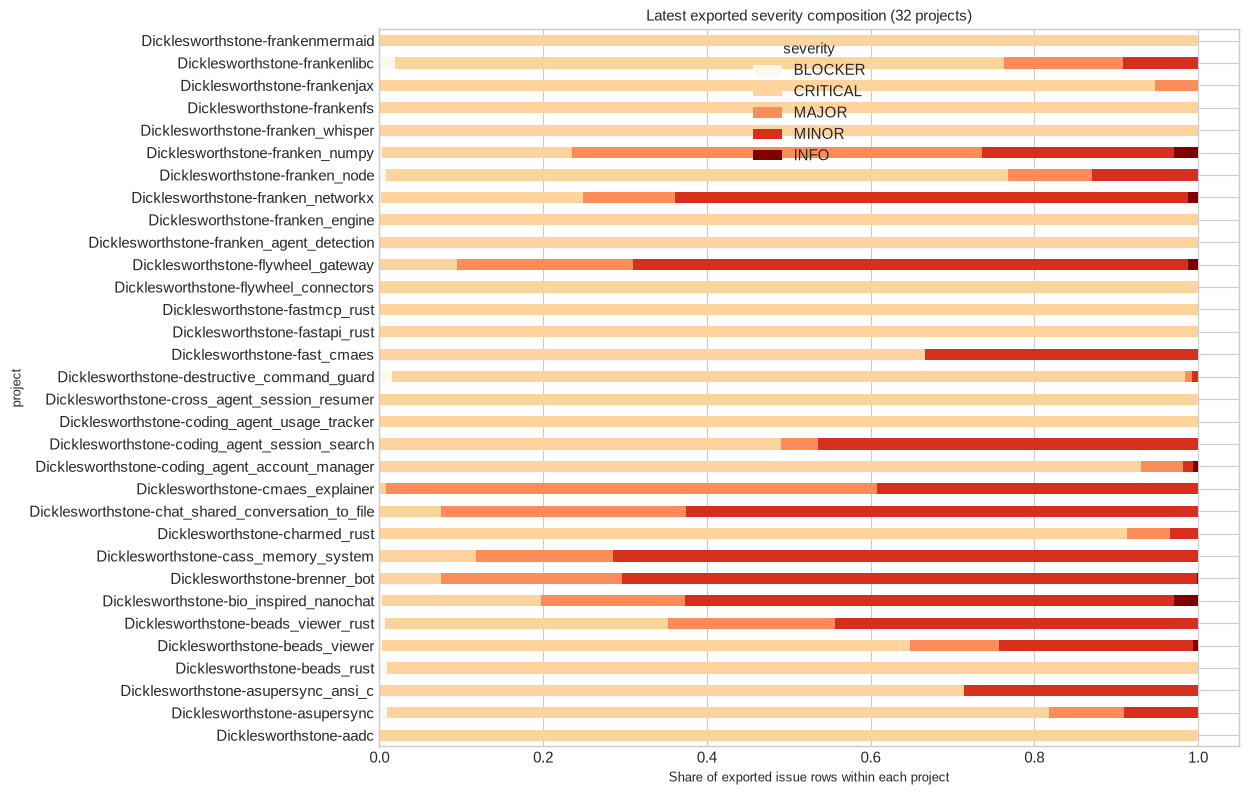

,projects_failing_condition
metric,
new_violations,84
new_coverage,63
new_duplicated_lines_density,37
new_security_hotspots_reviewed,29


In [8]:
issues = details["issues"]
if not issues.empty:
    severity = pd.crosstab(issues.project, issues.severity).reindex(columns=["BLOCKER", "CRITICAL", "MAJOR", "MINOR", "INFO"], fill_value=0)
    rules = issues.groupby(["rule_source", "rule", "severity"]).size().rename("exported_rows").sort_values(ascending=False)
    export_table(severity, "latest_issue_severity", index=True)
    export_table(rules, "latest_issue_rules", index=True)
    show_all(severity)
    display(rules.head(20).to_frame())
    fig, ax = plt.subplots(figsize=(12, max(4, .24 * len(severity))))
    severity.div(severity.sum(axis=1), axis=0).plot.barh(stacked=True, ax=ax, colormap="OrRd")
    ax.set_xlabel("Share of exported issue rows within each project")
    ax.set_title(f"Latest exported severity composition ({len(severity)} projects)")
    finish_figure(fig, "latest_issue_composition")
else:
    display(Markdown("No populated issue details at unambiguous latest snapshots in this window."))
gate_failures = details["gate_failures"]
export_table(gate_failures, "latest_gate_failures")
if not gate_failures.empty:
    metric_column = next((c for c in ["metric", "metricKey"] if c in gate_failures), None)
    if metric_column:
        display(gate_failures.groupby(metric_column).project.nunique().rename("projects_failing_condition").sort_values(ascending=False).to_frame())
else:
    display(Markdown("No parsed failed gate conditions in the selected latest snapshots."))


## 9. Select any project for detailed inspection

Set `PROJECT_TO_INSPECT` in the configuration cell, or change `selected_project`
below and rerun this cell. The default is data-driven, not a fixed case-study
list. All other projects remain present in the preceding analyses and exports.
The table includes remediation burden, function-size tails, comments/duplication,
static test paths, dependency coupling and history proxies. History churn per
commit is **not** the sampled commit's patch size. There is no direct cohesion
measurement here. Latest hotspots are omitted if latest-day order is ambiguous.


,artifact_snapshots,usable_snapshots,complete_csv_snapshots,zero_byte_workbooks,first_artifact_date,last_artifact_date,observed_days,date_mismatches,issue_snapshots,function_snapshots,zero_ncloc_snapshots,snapshots_in_window
project,,,,,,,,,,,,
gastownhall-gastown,254,254,254,0,2025-12-15,2026-03-05,79,108,0,254,0,254


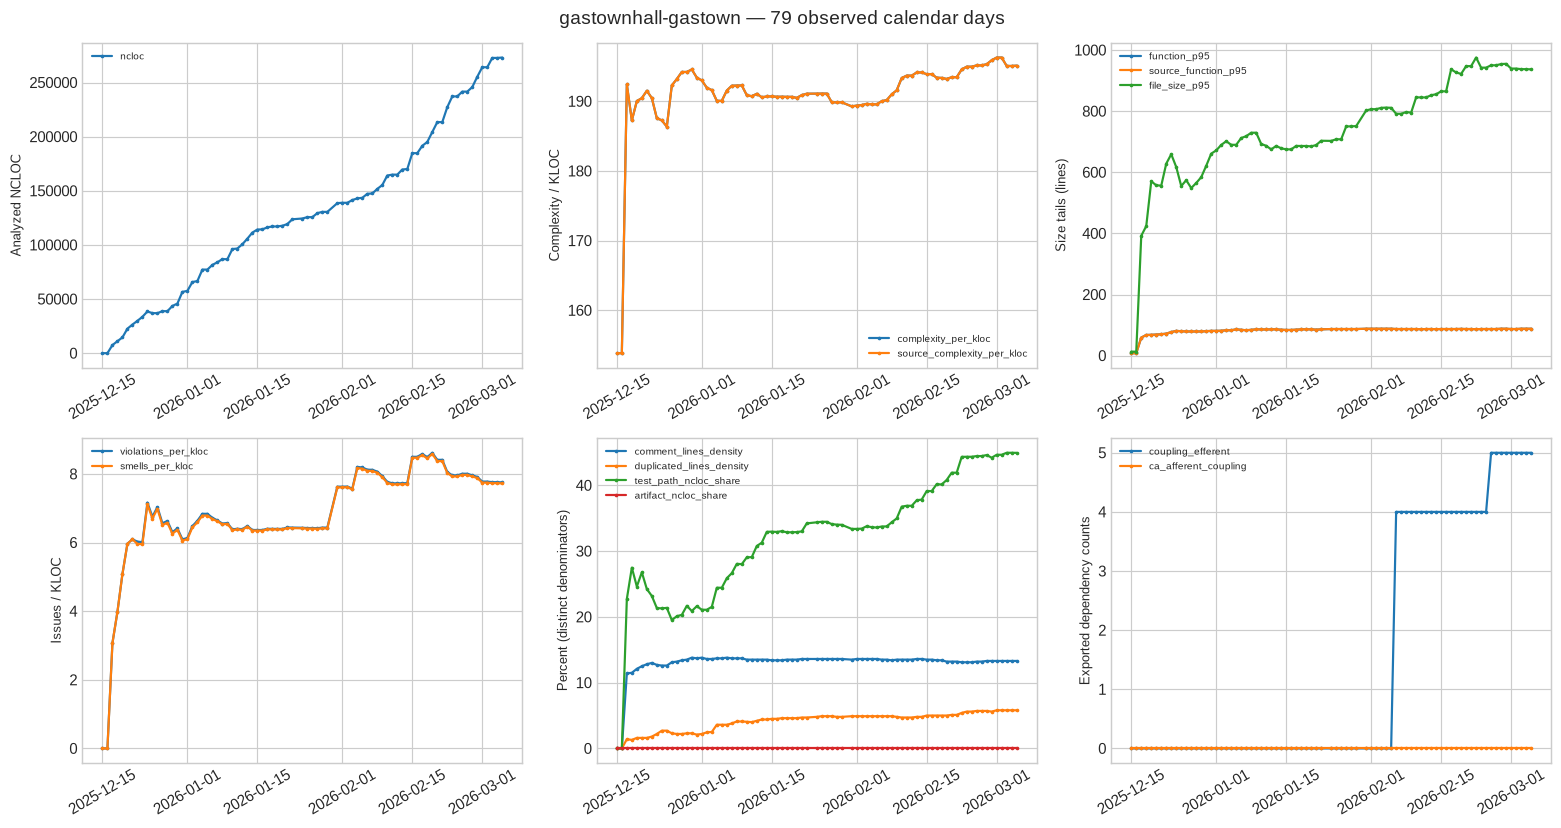

,date,ncloc,files,functions,complexity_per_kloc,cognitive_per_kloc,debt_per_kloc,function_median,function_p95,function_p99,function_share_gt100,git_scattering,git_churn_commits,churn_lines_per_history_commit,coupling_imports,coupling_efferent,ca_afferent_coupling
3382,2026-02-22,227221.0,957.0,8286.0,194.568284,221.608038,94.331070,21.0,86.425,152.985,3.261479,22.7,9142.0,73.933166,4.0,4.0,0.0
3383,2026-02-23,237160.0,994.0,8572.0,194.965424,222.351999,94.539551,21.0,87.000,153.000,3.435619,22.0,9638.0,74.153870,4.0,4.0,0.0
3384,2026-02-24,237160.0,994.0,8572.0,194.965424,222.351999,94.539551,21.0,87.000,153.000,3.437348,22.0,9638.0,74.153870,4.0,4.0,0.0
3385,2026-02-25,241592.0,1009.0,8724.0,195.151330,222.921289,95.694394,21.0,87.000,153.000,3.441660,21.5,9918.0,73.192478,5.0,5.0,0.0
3386,2026-02-26,241592.0,1009.0,8724.0,195.151330,222.921289,95.694394,21.0,87.000,153.000,3.440835,21.5,9918.0,73.192478,5.0,5.0,0.0
3387,2026-02-27,245767.0,1023.0,8870.0,195.323213,223.618305,96.465351,21.0,88.000,154.520,3.445428,21.1,10103.0,73.433733,5.0,5.0,0.0
3388,2026-02-28,255301.0,1076.0,9196.0,195.886424,223.943502,96.266760,21.0,88.000,153.000,3.465515,20.5,10460.0,72.906310,5.0,5.0,0.0
3389,2026-03-01,264108.0,1104.0,9630.0,196.279552,223.007255,94.711254,21.0,87.000,153.000,3.292762,19.8,11090.0,71.633273,5.0,5.0,0.0
3390,2026-03-02,264108.0,1104.0,9630.0,196.279552,223.007255,94.711254,21.0,87.000,153.000,3.282252,19.8,11090.0,71.633273,5.0,5.0,0.0
3391,2026-03-03,272708.0,1143.0,9915.0,195.069452,221.559324,94.544348,21.0,88.000,153.000,3.390008,19.9,11395.0,71.443352,5.0,5.0,0.0


,project,metric,days,first_date,last_date,first,last,delta,relative_change_pct,time_rank_rho
635,gastownhall-gastown,ncloc,79,2025-12-15,2026-03-05,13.000000,273073.000000,273060.000000,2.100462e+06,0.999738
636,gastownhall-gastown,complexity_per_kloc,79,2025-12-15,2026-03-05,153.846154,195.116324,41.270170,2.682561e+01,0.562757
637,gastownhall-gastown,cognitive_per_kloc,79,2025-12-15,2026-03-05,76.923077,221.548817,144.625740,1.880135e+02,0.971645
638,gastownhall-gastown,violations_per_kloc,79,2025-12-15,2026-03-05,0.000000,7.752506,7.752506,NaN,0.805032
639,gastownhall-gastown,debt_per_kloc,79,2025-12-15,2026-03-05,0.000000,94.454596,94.454596,NaN,0.906183
640,gastownhall-gastown,function_p95,79,2025-12-15,2026-03-05,8.000000,88.000000,80.000000,1.000000e+03,0.884176
641,gastownhall-gastown,comment_lines_density,79,2025-12-15,2026-03-05,0.000000,13.300000,13.300000,NaN,0.010226
642,gastownhall-gastown,duplicated_lines_density,79,2025-12-15,2026-03-05,0.000000,5.800000,5.800000,NaN,0.969716


,file,ncloc,complexity,cognitive_complexity,code_smells,bugs,vulnerabilities,duplicated_lines_density,comment_lines_density,sqale_index,git_scattering,git_scattering_commits_analyzed,git_churn_commits,coupling_efferent,coupling_imports,ca_afferent_coupling,ca_internal_imports,project
410,internal/web/static/dashboard.js,2534,868,1261,568,2,0,0.7,11.4,3078,4.66667,24,18,0,0,0,0,gastownhall-gastown
411,internal/config/loader_test.go,4154,766,992,19,0,0,10.6,6.1,369,19.87805,82,64,0,0,0,0,gastownhall-gastown
412,internal/doltserver/doltserver.go,2109,567,807,26,0,0,1.2,23.7,478,5.67308,104,88,0,0,0,0,gastownhall-gastown
413,internal/doltserver/doltserver_test.go,2794,711,714,7,0,0,7.8,10.0,133,4.42593,54,44,0,0,0,0,gastownhall-gastown
414,internal/config/loader.go,1723,546,625,18,0,0,8.7,19.9,305,18.27723,101,77,0,0,0,0,gastownhall-gastown


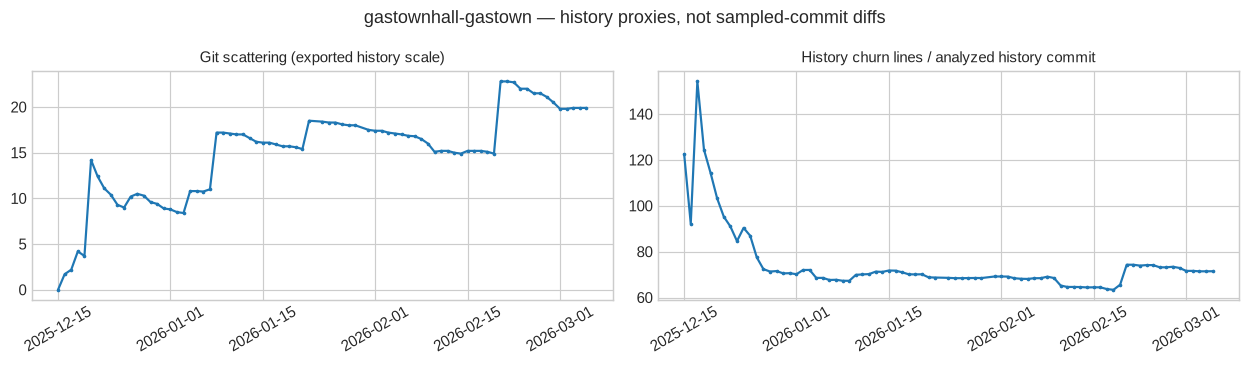

Latest exported source-like file scattering: top 10 (history window/formula unverified; pairs may be symmetric)

,type,path,git_scattering,commits_analyzed,top_coupled_files
0,FILE,internal/util/url_test.go,130.000000,4,internal/cmd/rig.go (4) | internal/crew/manager.go (4) | inte...
1,FILE,internal/util/url.go,130.000000,4,internal/cmd/rig.go (4) | internal/crew/manager.go (4) | inte...
2,FILE,internal/cmd/close_test.go,127.750000,4,internal/cmd/close.go (4) | .beads/formulas/mol-deacon-patrol...
3,FILE,internal/util/exec_windows.go,113.000000,7,internal/cmd/convoy.go (7) | internal/cmd/convoy_empty_test.g...
4,FILE,internal/util/exec_unix.go,113.000000,7,internal/cmd/convoy.go (7) | internal/cmd/convoy_empty_test.g...
5,FILE,internal/cmd/rig_list_test.go,110.428571,7,internal/cmd/rig.go (7) | internal/cmd/statusline.go (7) | .g...
6,FILE,internal/beads/config_yaml.go,110.400000,5,internal/beads/config_yaml_test.go (5) | internal/cmd/deacon....
7,FILE,internal/cmd/install_test.go,110.400000,5,internal/beads/config_yaml.go (5) | internal/beads/config_yam...
8,FILE,internal/beads/config_yaml_test.go,110.400000,5,internal/beads/config_yaml.go (5) | internal/cmd/deacon.go (5...
9,FILE,internal/doctor/bare_repo_exists_check_test.go,104.400000,5,internal/doctor/rig_check.go (5) | internal/cmd/doctor.go (4)...


Latest exported source-like file pairs: top 10 (history window/formula unverified; pairs may be symmetric)

,type,path,coupled_file,shared_commits
124,FILE,internal/refinery/manager.go,internal/witness/manager.go,61
125,FILE,internal/witness/manager.go,internal/refinery/manager.go,61
127,FILE,internal/config/loader_test.go,internal/config/loader.go,60
128,FILE,internal/config/loader.go,internal/config/loader_test.go,60
133,FILE,internal/daemon/lifecycle.go,internal/daemon/daemon.go,53
134,FILE,internal/daemon/daemon.go,internal/daemon/lifecycle.go,53
136,FILE,internal/tmux/tmux.go,internal/tmux/tmux_test.go,52
137,FILE,internal/tmux/tmux_test.go,internal/tmux/tmux.go,52
140,FILE,internal/doltserver/doltserver_test.go,internal/doltserver/doltserver.go,50
141,FILE,internal/doltserver/doltserver.go,internal/doltserver/doltserver_test.go,50


In [9]:
selected_project = PROJECT_TO_INSPECT or snapshots.groupby("project").size().idxmax()
if selected_project not in inventory.index:
    raise ValueError(f"Unknown project: {selected_project}. Choose from the inventory table.")
display(inventory.loc[[selected_project]])
rq4.project_profile(selected_project, daily, snapshots, details, OUTPUT_DIR)
profile_columns = ["date", "ncloc", "files", "functions", "complexity_per_kloc", "cognitive_per_kloc", "debt_per_kloc", "function_median", "function_p95", "function_p99", "function_share_gt100", "git_scattering", "git_churn_commits", "churn_lines_per_history_commit", "coupling_imports", "coupling_efferent", "ca_afferent_coupling"]
display(daily.loc[daily.project.eq(selected_project), profile_columns].tail(12))
display(endpoints[endpoints.project.eq(selected_project)])
if selected_project in details["ambiguous_latest"].index:
    display(Markdown("Multiple snapshots share the latest sampling date; no arbitrary revision was selected for hotspots."))
elif not details["hotspots"].empty:
    display(details["hotspots"].loc[details["hotspots"].project.eq(selected_project)])
history_tables = rq4.history_profile(selected_project, daily, manifest, details, OUTPUT_DIR)
for name, table in history_tables.items():
    display(Markdown(f'Latest exported source-like file {name}: top 10 (history window/formula unverified; pairs may be symmetric)'))
    display(table)
    export_table(table, f'{name}-{selected_project}')


## 10. Reading the results against RQ4

- **H4.1/H4.2:** commit size/breadth, tests touched by fixes, conventional messages,
  and attribution contrasts require the cached commit/file-detail and agent-signal
  join. Repository snapshot metrics do not answer these hypotheses by themselves.
- **H4.3:** the notebook now describes all projects' complexity density and size
  tails, aggregate calendar levels, and changes in comparable adjacent-month
  project pairs. Associations with volume require interval exposure and controls
  for maturation, language/scope changes and temporal dependence. Snapshot counts
  are sampling effort, not commit volume.
- **ASAT:** use normalized burden, rule composition and explicit gate conditions
  as complementary evidence. Sparse issue exports, unmeasured tests and unsupported
  languages limit comparisons. Neither a positive slope nor a failed quality gate
  establishes poor external behavior or an AI-caused defect.

Before paper claims: validate the revision/date manifest and extraction settings,
choose the cohort/window and source exclusions, inspect outliers, join full-SHA
commits with completeness flags, and keep attribution separate from verified
authorship. The CSV/PDF exports make the current descriptive results reviewable
without implying that these unresolved methodological steps have been completed.


In [10]:
run_metadata = {
    "start_date": START_DATE, "end_date": END_DATE,
    "projects_in_artifacts": int(manifest.project.nunique()),
    "projects_analyzed": int(snapshots.project.nunique()),
    "snapshots_analyzed": len(snapshots), "project_days": len(daily),
    "calendar_policy": "filename sampling date; median across same-project same-day snapshots; no imputation",
    "monthly_policy": "median across observed days per project, equal project weight; adjacent calendar-month pairs",
    "python": sys.version, "pandas": pd.__version__, "numpy": np.__version__,
}
(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2) + "\n")
display(Markdown(f"Tables and figures saved to `{OUTPUT_DIR.relative_to(REPO_ROOT)}/`. "
                 "See `project_inventory.csv`, `project_daily_metrics.csv`, `project_endpoints.csv`, "
                 "and `all_project_trajectories.pdf` for coverage of every project."))


Tables and figures saved to `figures/rq4/outputs/`. See `project_inventory.csv`, `project_daily_metrics.csv`, `project_endpoints.csv`, and `all_project_trajectories.pdf` for coverage of every project.